In [106]:
# QUICK RESTART - run this instead of rerunning everything from scratch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve

# Load train/test split
X_train, X_test, y_train, y_test = pickle.load(open('train_test_split.pkl', 'rb'))
X_dates_train, X_dates_test, y_dates_train, y_dates_test = pickle.load(open('train_test_split_dates.pkl', 'rb'))

# Load scaled data (for logistic regression models)
X_train_scaled, X_test_scaled, _, _ = pickle.load(open('scaled_data.pkl', 'rb'))


# Load models
lr = pickle.load(open('lr.pkl', 'rb'))
lr_balanced = pickle.load(open('lr_balanced.pkl', 'rb'))
lr_l1 = pickle.load(open('lr_l1.pkl', 'rb'))
lr_l2 = pickle.load(open('lr_l2.pkl', 'rb'))
xgb = pickle.load(open('xgb.pkl', 'rb'))
best_xgb = pickle.load(open('xgb_best.pkl', 'rb'))
rf = pickle.load(open('rf.pkl', 'rb'))


# Regenerate predictions
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_prob_lr_balanced = lr_balanced.predict_proba(X_test_scaled)[:, 1]
y_prob_l1 = lr_l1.predict_proba(X_test_scaled)[:, 1]
y_prob_l2 = lr_l2.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_best_xgb = best_xgb.predict(X_test)
y_prob_best_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('All loaded successfully')

All loaded successfully


In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_pickle('df_original.pkl')
print(df.shape)
print(df.columns.tolist())
print(df.head())

(2260701, 151)
['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'a

In [108]:
df.to_pickle('df_original.pkl')

In [109]:
df.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,...,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.0,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260668e+06,2.260664e+06,2.258957e+06,2.260639e+06,2.260668e+06,2.260668e+06,2.260638e+06,1.102166e+06,359156.000000,2.260639e+06,...,108021.000000,108021.000000,108021.000000,108021.000000,35942.000000,10917.0,10917.000000,10917.0,10917.000000,8651.000000,10917.000000,10917.000000,34246.000000,34246.000000,34246.000000
mean,NaN,1.504693e+04,1.504166e+04,1.502344e+04,1.309283e+01,4.458068e+02,7.799243e+04,1.882420e+01,3.068792e-01,6.985882e+02,7.025884e+02,5.768354e-01,3.454092e+01,72.312842,1.161240e+01,...,3.010554,12.533072,0.046352,0.077568,36.937928,3.0,155.045981,3.0,13.743886,454.798089,11636.883942,193.994321,5010.664267,47.780365,13.191322
std,NaN,9.190245e+03,9.188413e+03,9.192332e+03,4.832138e+00,2.671735e+02,1.126962e+05,1.418333e+01,8.672303e-01,3.301038e+01,3.301124e+01,8.859632e-01,2.190047e+01,26.464094,5.640861e+00,...,3.275893,8.150964,0.411496,0.407996,23.924584,0.0,129.040594,0.0,9.671178,375.385500,7625.988281,198.629496,3693.122590,7.311822,8.159980
min,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,6.100000e+02,6.140000e+02,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,44.210000,0.200000,0.000000
25%,NaN,8.000000e+03,8.000000e+03,8.000000e+03,9.490000e+00,2.516500e+02,4.600000e+04,1.189000e+01,0.000000e+00,6.750000e+02,6.790000e+02,0.000000e+00,1.600000e+01,55.000000,8.000000e+00,...,1.000000,7.000000,0.000000,0.000000,16.000000,3.0,59.440000,3.0,5.000000,175.230000,5627.000000,44.440000,2208.000000,45.000000,6.000000
50%,NaN,1.290000e+04,1.287500e+04,1.280000e+04,1.262000e+01,3.779900e+02,6.500000e+04,1.784000e+01,0.000000e+00,6.900000e+02,6.940000e+02,0.000000e+00,3.100000e+01,74.000000,1.100000e+01,...,2.000000,11.000000,0.000000,0.000000,36.000000,3.0,119.140000,3.0,15.000000,352.770000,10028.390000,133.160000,4146.110000,45.000000,14.000000
75%,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.933200e+02,9.300000e+04,2.449000e+01,0.000000e+00,7.150000e+02,7.190000e+02,1.000000e+00,5.000000e+01,92.000000,1.400000e+01,...,4.000000,17.000000,0.000000,0.000000,56.000000,3.0,213.260000,3.0,22.000000,620.175000,16151.890000,284.190000,6850.172500,50.000000,18.000000
max,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,5.800000e+01,8.450000e+02,8.500000e+02,3.300000e+01,2.260000e+02,129.000000,1.010000e+02,...,43.000000,106.000000,21.000000,23.000000,185.000000,3.0,943.940000,3.0,37.000000,2680.890000,40306.410000,1407.860000,33601.000000,521.350000,181.000000


Data Prep


1. Filtering for completed loans only

In [110]:
#print the unique values that loan_status can take
print(f"Unique loan status: {df.loan_status.unique()}")

Unique loan status: ['Fully Paid' 'Current' 'Charged Off' 'In Grace Period'
 'Late (31-120 days)' 'Late (16-30 days)' 'Default' nan
 'Does not meet the credit policy. Status:Fully Paid'
 'Does not meet the credit policy. Status:Charged Off']


Get rid of: 'Current', 'In Grace Period', 'Late (31-120 days)', 'Late (16-30 days)', 'nan'

In [111]:
print(df.shape)

(2260701, 151)


In [112]:
#safer to filter for completed ones as this means any unexpected values are automatically filtered out
completed = [
    'Fully Paid', 'Charged Off', 'Default', 
    'Does not meet the credit policy. Status:Fully Paid', 
    'Does not meet the credit policy. Status:Charged Off'
]
df = df[df['loan_status'].isin(completed)]

#confirm it worked
print(df['loan_status'].value_counts())

loan_status
Fully Paid                                             1076751
Charged Off                                             268559
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


2. Get rid of post-loan data to prevent leakage

In [113]:
#Looking at the data dictionary we remove the following
post_loan = [
    # Post-loan payment data
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
    'recoveries', 'collection_recovery_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
    'last_fico_range_high', 'last_fico_range_low',
    # Hardship data
    'hardship_flag', 'hardship_type', 'hardship_reason', 'hardship_status',
    'deferral_term', 'hardship_amount', 'hardship_start_date',
    'hardship_end_date', 'payment_plan_start_date', 'hardship_length',
    'hardship_dpd', 'hardship_loan_status',
    'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
    # Settlement data
    'debt_settlement_flag', 'debt_settlement_flag_date', 'settlement_status',
    'settlement_date', 'settlement_amount', 'settlement_percentage',
    'settlement_term'
]

df = df.drop(columns=post_loan)
print(df.shape)

(1348099, 114)


We will also look at irrelevant data or data there isn't enough of to be relevant  
int_rate could be considered post loan data potentially as it will be set partially based on risk

In [114]:
#remove irrelevant data
drop_irrelevant = [
    # Identifiers and useless columns
    'id', 'member_id', 'url', 'desc', 'title', 'zip_code',
    'policy_code', 'pymnt_plan', 'funded_amnt', 'funded_amnt_inv',
    # Joint application columns (won't be much data as most aren't joint applications)
    'annual_inc_joint', 'dti_joint', 'verification_status_joint',
    'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_fico_range_high',
    'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc',
    'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il',
    'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12_mths',
    'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog',
    # Free text, too messy to model
    'emp_title',
    # Low predictive value
    'initial_list_status', 'disbursement_method',
    # Borderline post-loan
    'acc_now_delinq', 'delinq_amnt', 'chargeoff_within_12_mths',
    # Granular credit bureau fields - overlap with simpler kept columns
    # e.g. pub_rec, revol_util already capture this information
    'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'avg_cur_bal',
    'bc_open_to_buy', 'bc_util', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mths_since_recent_bc',
    'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl',
    'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl',
    'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats',
    'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m',
    'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75',
    'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort',
    'total_bc_limit', 'total_il_high_credit_limit',
    'acc_open_past_24mths', 'collections_12_mths_ex_med'
]

df = df.drop(columns=drop_irrelevant)
print(df.shape)

(1348099, 47)


In [115]:
#data that is limited
for column in df.columns:
    if df[column].isna().sum() != 0:
        missing = df[column].isna().sum()
        portion = (missing / df.shape[0]) * 100
        print(f"'{column}': number of missing values '{missing}' ==> '{portion:.3f}%'")


'emp_length': number of missing values '78550' ==> '5.827%'
'annual_inc': number of missing values '4' ==> '0.000%'
'dti': number of missing values '374' ==> '0.028%'
'delinq_2yrs': number of missing values '29' ==> '0.002%'
'earliest_cr_line': number of missing values '29' ==> '0.002%'
'inq_last_6mths': number of missing values '30' ==> '0.002%'
'mths_since_last_delinq': number of missing values '679960' ==> '50.438%'
'mths_since_last_record': number of missing values '1118675' ==> '82.982%'
'open_acc': number of missing values '29' ==> '0.002%'
'pub_rec': number of missing values '29' ==> '0.002%'
'revol_util': number of missing values '897' ==> '0.067%'
'total_acc': number of missing values '29' ==> '0.002%'
'mths_since_last_major_derog': number of missing values '994342' ==> '73.759%'
'open_acc_6m': number of missing values '810464' ==> '60.119%'
'open_act_il': number of missing values '810463' ==> '60.119%'
'open_il_12m': number of missing values '810463' ==> '60.119%'
'open_il_24

In [116]:
print(df.columns.tolist())

['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mths_since_last_major_derog', 'application_type', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'mort_acc', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'pub_rec_bankruptcies']


In [117]:
more_irrelevant = [
    'mths_since_last_delinq', 'mths_since_last_record', 
    'mths_since_last_major_derog', 'open_acc_6m', 'open_act_il',
    'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
    'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m',
    'max_bal_bc', 'all_util', 'inq_fi', 'total_cu_tl', 
    'inq_last_12m', 'mths_since_recent_bc_dlq', 
    'mths_since_recent_revol_delinq'
]

df = df.drop(columns=more_irrelevant)
print(df.shape)

(1348099, 28)


In [118]:
pd.set_option('display.max_columns', 30)
print(df.head())

   loan_amnt        term  int_rate  installment grade sub_grade emp_length  \
0     3600.0   36 months     13.99       123.03     C        C4  10+ years   
1    24700.0   36 months     11.99       820.28     C        C1  10+ years   
2    20000.0   60 months     10.78       432.66     B        B4  10+ years   
4    10400.0   60 months     22.45       289.91     F        F1    3 years   
5    11950.0   36 months     13.44       405.18     C        C3    4 years   

  home_ownership  annual_inc verification_status   issue_d loan_status  \
0       MORTGAGE     55000.0        Not Verified  Dec-2015  Fully Paid   
1       MORTGAGE     65000.0        Not Verified  Dec-2015  Fully Paid   
2       MORTGAGE     63000.0        Not Verified  Dec-2015  Fully Paid   
4       MORTGAGE    104433.0     Source Verified  Dec-2015  Fully Paid   
5           RENT     34000.0     Source Verified  Dec-2015  Fully Paid   

              purpose addr_state    dti  delinq_2yrs earliest_cr_line  \
0  debt_conso

In [119]:
df["application_type"].value_counts()

application_type
Individual    1322293
Joint App       25806
Name: count, dtype: int64

In [120]:
#Drop joint applications as this is a small percentage
df = df[df['application_type'] == 'Individual']
df = df.drop(columns=['application_type'])

Take weighted average of fico range high and low

In [121]:
df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high'])/2
df = df.drop(columns=['fico_range_low', 'fico_range_high'])

In [122]:
print(df.shape)

(1322293, 26)


In [123]:
#See what missing data remains
for column in df.columns:
    if df[column].isna().sum() != 0:
        missing = df[column].isna().sum()
        portion = (missing / df.shape[0]) * 100
        print(f"'{column}': number of missing values '{missing}' ==> '{portion:.3f}%'")

'emp_length': number of missing values '74802' ==> '5.657%'
'annual_inc': number of missing values '4' ==> '0.000%'
'delinq_2yrs': number of missing values '29' ==> '0.002%'
'earliest_cr_line': number of missing values '29' ==> '0.002%'
'inq_last_6mths': number of missing values '30' ==> '0.002%'
'open_acc': number of missing values '29' ==> '0.002%'
'pub_rec': number of missing values '29' ==> '0.002%'
'revol_util': number of missing values '852' ==> '0.064%'
'total_acc': number of missing values '29' ==> '0.002%'
'mort_acc': number of missing values '50030' ==> '3.784%'
'pub_rec_bankruptcies': number of missing values '1365' ==> '0.103%'


In [124]:
#For all but emp_length and mort_acc, there are tiny portions so we remove the ones with na
df = df.dropna(subset=[
    'annual_inc', 'delinq_2yrs', 'earliest_cr_line', 
    'inq_last_6mths', 'open_acc', 'pub_rec', 
    'revol_util', 'total_acc', 'pub_rec_bankruptcies'
])

In [125]:
#remove state and change earliest_cr_line to months before issue date
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])
df['issue_d'] = pd.to_datetime(df['issue_d'])
df['credit_history_months'] = ((df['issue_d'] - df['earliest_cr_line']) / pd.Timedelta(days=30)).astype(int)
df = df.drop(columns=['earliest_cr_line', 'addr_state'])
print(df.shape)

/var/folders/0w/5zj59q2d019fvdknt0sq1g740000gn/T/ipykernel_59200/1655909202.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])
/var/folders/0w/5zj59q2d019fvdknt0sq1g740000gn/T/ipykernel_59200/1655909202.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_d'] = pd.to_datetime(df['issue_d'])


(1320107, 25)


In [126]:
print(df.head())

   loan_amnt        term  int_rate  installment grade sub_grade emp_length  \
0     3600.0   36 months     13.99       123.03     C        C4  10+ years   
1    24700.0   36 months     11.99       820.28     C        C1  10+ years   
4    10400.0   60 months     22.45       289.91     F        F1    3 years   
5    11950.0   36 months     13.44       405.18     C        C3    4 years   
6    20000.0   36 months      9.17       637.58     B        B2  10+ years   

  home_ownership  annual_inc verification_status    issue_d loan_status  \
0       MORTGAGE     55000.0        Not Verified 2015-12-01  Fully Paid   
1       MORTGAGE     65000.0        Not Verified 2015-12-01  Fully Paid   
4       MORTGAGE    104433.0     Source Verified 2015-12-01  Fully Paid   
5           RENT     34000.0     Source Verified 2015-12-01  Fully Paid   
6       MORTGAGE    180000.0        Not Verified 2015-12-01  Fully Paid   

              purpose    dti  delinq_2yrs  inq_last_6mths  open_acc  pub_rec  \


In [127]:
#grade is just a more vague version of subgrade so we remove
df = df.drop(columns='grade')

Now we look at the remaining outliers from emp_length and mort_acc

In [128]:
print(df['emp_length'].value_counts())

emp_length
10+ years    435656
2 years      119997
3 years      106107
< 1 year     102589
1 year        87336
5 years       82989
4 years       79382
6 years       61962
8 years       60037
7 years       58936
9 years       50355
Name: count, dtype: int64


In [129]:
#We will replace the na with unknown for now as there may be a link between people
#not specifying
df['emp_length'] = df['emp_length'].fillna('Unknown')

In [130]:
#mort_acc is numerical so we fill with the median
df['mort_acc'] = df['mort_acc'].fillna(df['mort_acc'].median())

In [131]:
print(df.head())

   loan_amnt        term  int_rate  installment sub_grade emp_length  \
0     3600.0   36 months     13.99       123.03        C4  10+ years   
1    24700.0   36 months     11.99       820.28        C1  10+ years   
4    10400.0   60 months     22.45       289.91        F1    3 years   
5    11950.0   36 months     13.44       405.18        C3    4 years   
6    20000.0   36 months      9.17       637.58        B2  10+ years   

  home_ownership  annual_inc verification_status    issue_d loan_status  \
0       MORTGAGE     55000.0        Not Verified 2015-12-01  Fully Paid   
1       MORTGAGE     65000.0        Not Verified 2015-12-01  Fully Paid   
4       MORTGAGE    104433.0     Source Verified 2015-12-01  Fully Paid   
5           RENT     34000.0     Source Verified 2015-12-01  Fully Paid   
6       MORTGAGE    180000.0        Not Verified 2015-12-01  Fully Paid   

              purpose    dti  delinq_2yrs  inq_last_6mths  open_acc  pub_rec  \
0  debt_consolidation   5.91        

In [132]:
print(df.columns.tolist())

['loan_amnt', 'term', 'int_rate', 'installment', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'fico_avg', 'credit_history_months']


Note that we are keeping issue date for now for the split but this will be removed before training and stuff
May later consider dropping int rate and installment as these are partially derived from risk so may inflate the accuracy

In [133]:
print(df['loan_status'].value_counts())

loan_status
Fully Paid                                             1056069
Charged Off                                             261931
Does not meet the credit policy. Status:Fully Paid        1529
Does not meet the credit policy. Status:Charged Off        544
Default                                                     34
Name: count, dtype: int64


In [134]:
#default (=1) for Charged off, Does not meet the crediy policy. Status:Charged Off, and Default
#not default (=0) for Fully Paid, Does not meet the credit policy. Status:Fully Paid
default_status = [
    'Charged Off', 'Does not meet the credit policy. Status:Charged Off', 
    'Default'
]

df['default'] = df['loan_status'].isin(default_status).astype(int)
print(df['default'].value_counts())

default
0    1057598
1     262509
Name: count, dtype: int64


In [135]:
#now we can drop the loan_status column
df = df.drop(columns='loan_status')

In [136]:
print(df['default'].value_counts(normalize=True) * 100)

default
0    80.114566
1    19.885434
Name: proportion, dtype: float64


In [137]:
df.to_pickle('df_processed.pkl')

We see above that 80.1% of our data doesn't default and 19.1% does

Now it is time for the exploratory data analysis

Lets look at the breakdown of the data remaining

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1320107 entries, 0 to 2260697
Data columns (total 24 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   loan_amnt              1320107 non-null  float64       
 1   term                   1320107 non-null  object        
 2   int_rate               1320107 non-null  float64       
 3   installment            1320107 non-null  float64       
 4   sub_grade              1320107 non-null  object        
 5   emp_length             1320107 non-null  object        
 6   home_ownership         1320107 non-null  object        
 7   annual_inc             1320107 non-null  float64       
 8   verification_status    1320107 non-null  object        
 9   issue_d                1320107 non-null  datetime64[ns]
 10  purpose                1320107 non-null  object        
 11  dti                    1320107 non-null  float64       
 12  delinq_2yrs            1320107 no

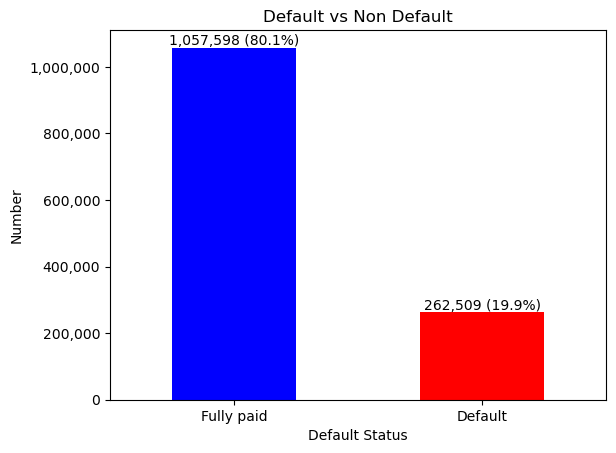

In [139]:
#Loan status
import matplotlib.ticker as ticker
ax = df['default'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Default vs Non Default')
plt.xlabel('Default Status')
plt.ylabel('Number')
plt.xticks([0, 1], ['Fully paid', 'Default'], rotation=0)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # format y axis with correct separators
for i, value in enumerate(df['default'].value_counts()):
    ax.text(i, value, f'{value:,.0f} ({value/(len(df))*100:.1f}%)', 
            ha='center', va='bottom')
plt.show()

The dataset is imbalanced with 80.1% of loans fully paid. This needs to be considered during modellling as a model predicting loan fully paid every time will achieve 80.1% accuracy.

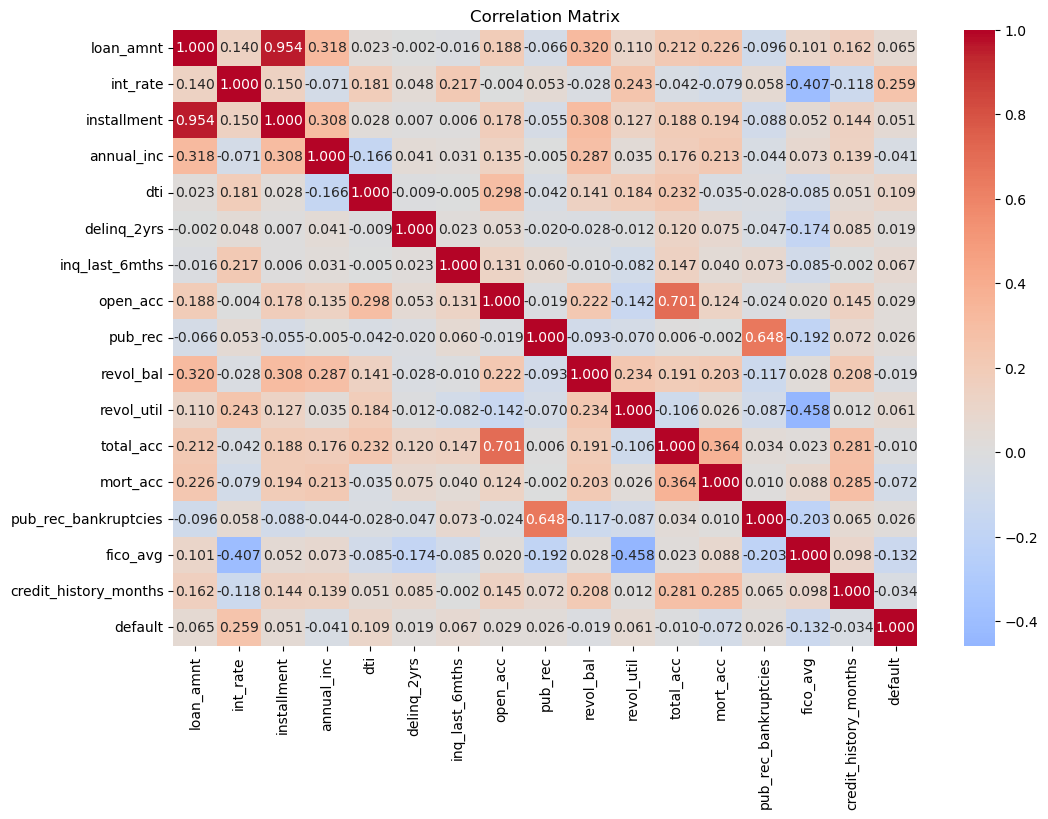

In [140]:
import seaborn as sns

corr = df.select_dtypes(include = 'number').corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt = '.3f', cmap='coolwarm', center = 0)
plt.title('Correlation Matrix')
plt.show()

Here we notice the following are highly correlated and therefore we can drop one  
loan_amnt and installment are highly correlated (0.954) which makes sense as higher installments are paid with larger loans. We will drop 'installment'  
We see a high correlation between open_acc and total_acc (0.701). open_acc gives a better idea of current situation so we will drop 'total_acc'  
pub_rec and pub_rec_bankruptcies are highly correlated (0.648). pub_rec is a measure of all public records whereas _bankruptcies measures solely bankruptcies. For now I will keep both as they are different enough, _bankruptcies is more specific and serious but there may be some tells if there are more, less serious public records.  
  
int_rate is the most correlated with default (0.259), this was suspected earlier as this is partially based on risk. Outside of this, fico_avg (-0.132) and dti (0.109) are the next most correlated.  
No individual variable has a strong correlation with default which confirms a model is required to capture the combined effects of the multiple variables.

In [141]:
#remove installment and total_acc
df = df.drop(columns=(['installment', 'total_acc']))

In [142]:
print(df.shape)

(1320107, 22)


We compare pub_rec and pub_rec_bankruptcies

In [143]:
print(f'pub_rec:{df['pub_rec'].value_counts()}')
print(f'pub_rec_bankruptcies:{df['pub_rec_bankruptcies'].value_counts()}')

pub_rec:pub_rec
0.0     1096692
1.0      186784
2.0       24115
3.0        7308
4.0        2597
5.0        1256
6.0         630
7.0         280
8.0         158
9.0          83
10.0         57
11.0         40
12.0         27
13.0         18
15.0          9
18.0          6
21.0          6
19.0          5
16.0          5
14.0          5
20.0          3
28.0          3
17.0          3
49.0          2
22.0          2
24.0          2
86.0          1
23.0          1
47.0          1
46.0          1
37.0          1
40.0          1
63.0          1
34.0          1
54.0          1
25.0          1
61.0          1
Name: count, dtype: int64
pub_rec_bankruptcies:pub_rec_bankruptcies
0.0     1156240
1.0      154035
2.0        7654
3.0        1568
4.0         395
5.0         141
6.0          45
7.0          15
8.0           9
9.0           3
11.0          1
12.0          1
Name: count, dtype: int64


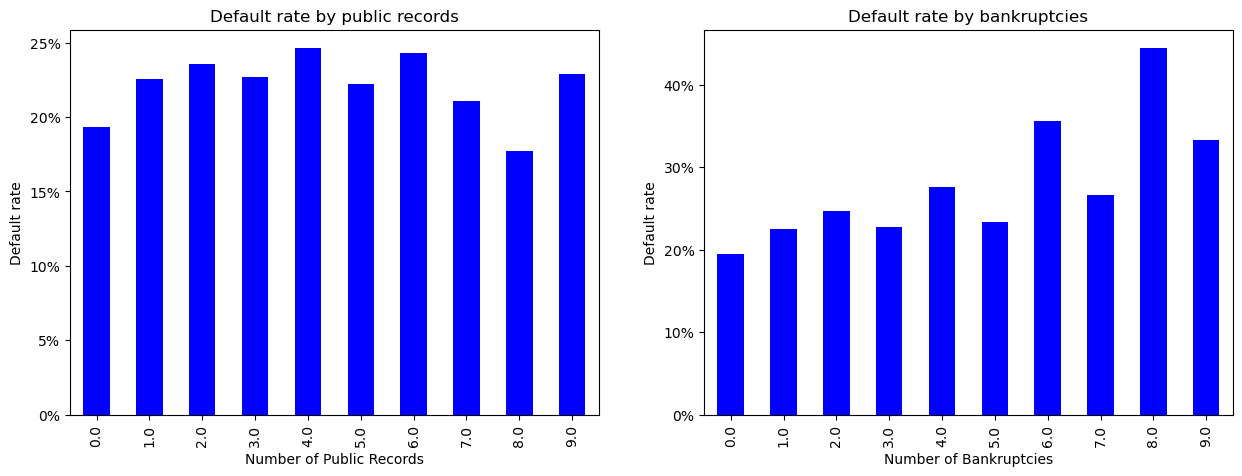

In [144]:
#above we see that there aren't many for either above 10 so we limit this so the axis isn't too big
fig, ax = plt.subplots(1, 2, figsize=(15,5))
#plot 1
df.groupby('pub_rec')['default'].mean().head(10).plot(kind='bar', color='blue', ax=ax[0])
ax[0].set_title('Default rate by public records')
ax[0].set_xlabel('Number of Public Records')
ax[0].set_ylabel('Default rate')
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))


#plot 2
df.groupby('pub_rec_bankruptcies')['default'].mean().head(10).plot(kind='bar', color='blue', ax=ax[1])
ax[1].set_title('Default rate by bankruptcies')
ax[1].set_xlabel('Number of Bankruptcies')
ax[1].set_ylabel('Default rate')
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.show()

This backs up the decision to keep both as there are different relationships with default rate. Public records on their own don't predict default rate - it stays at around 20% for all although it is interesting to see 0 is lower. Bankruptcies on the other hand has an upwards trend, especially at higher values although it is important to note that there aren't many people at 6+ so this is a small sample size.

Now I am going to plot the three variables that correlated the most with default rate: int_rate, fico_avg and dti

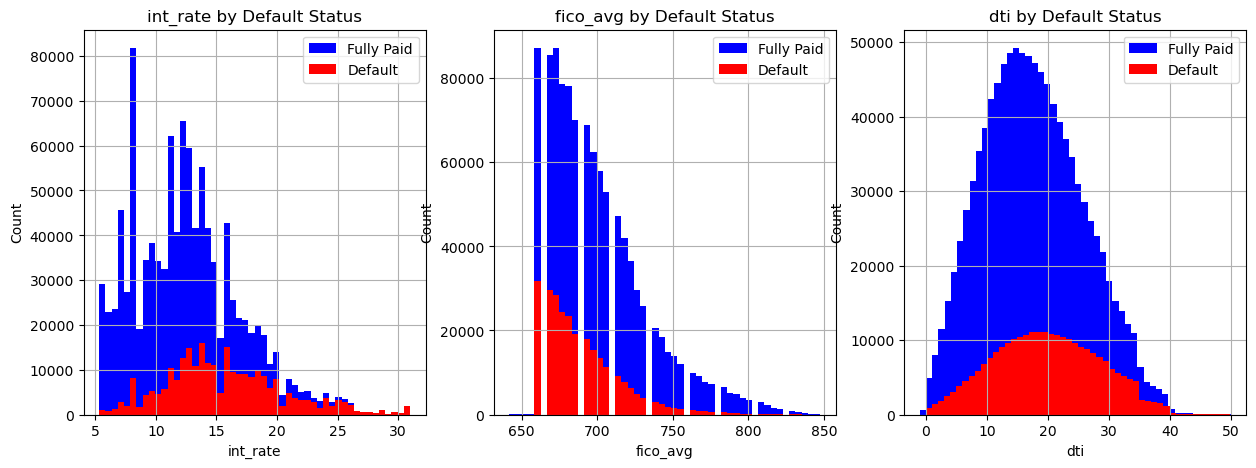

In [145]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
vars = ['int_rate', 'fico_avg', 'dti']

for i in range(len(vars)):
    df[df['default']==0][vars[i]].hist(label='Fully Paid', color='blue', bins=50, ax=ax[i])
    df[df['default']==1][vars[i]].hist(label='Default', color='red', bins=50, ax=ax[i])
    ax[i].set_title(f'{vars[i]} by Default Status')
    ax[i].set_xlabel(vars[i])
    ax[i].set_ylabel('Count')
    ax[i].legend()

plt.show()

int_rate: It is clear that this is the best predictor, there is a clear rightward shift for defaulters. The greates proportion of non-defaulters is from 5-15% whereas defaulters are spread out at higher rates.  

fico_avg: Defaulters sit clearly to the left, and there are almost none with a credit score higher than 750.  

dti: Both are similarly distributed, however defaulters have a more prominent rightward tail.

Now we look at the categorical variables

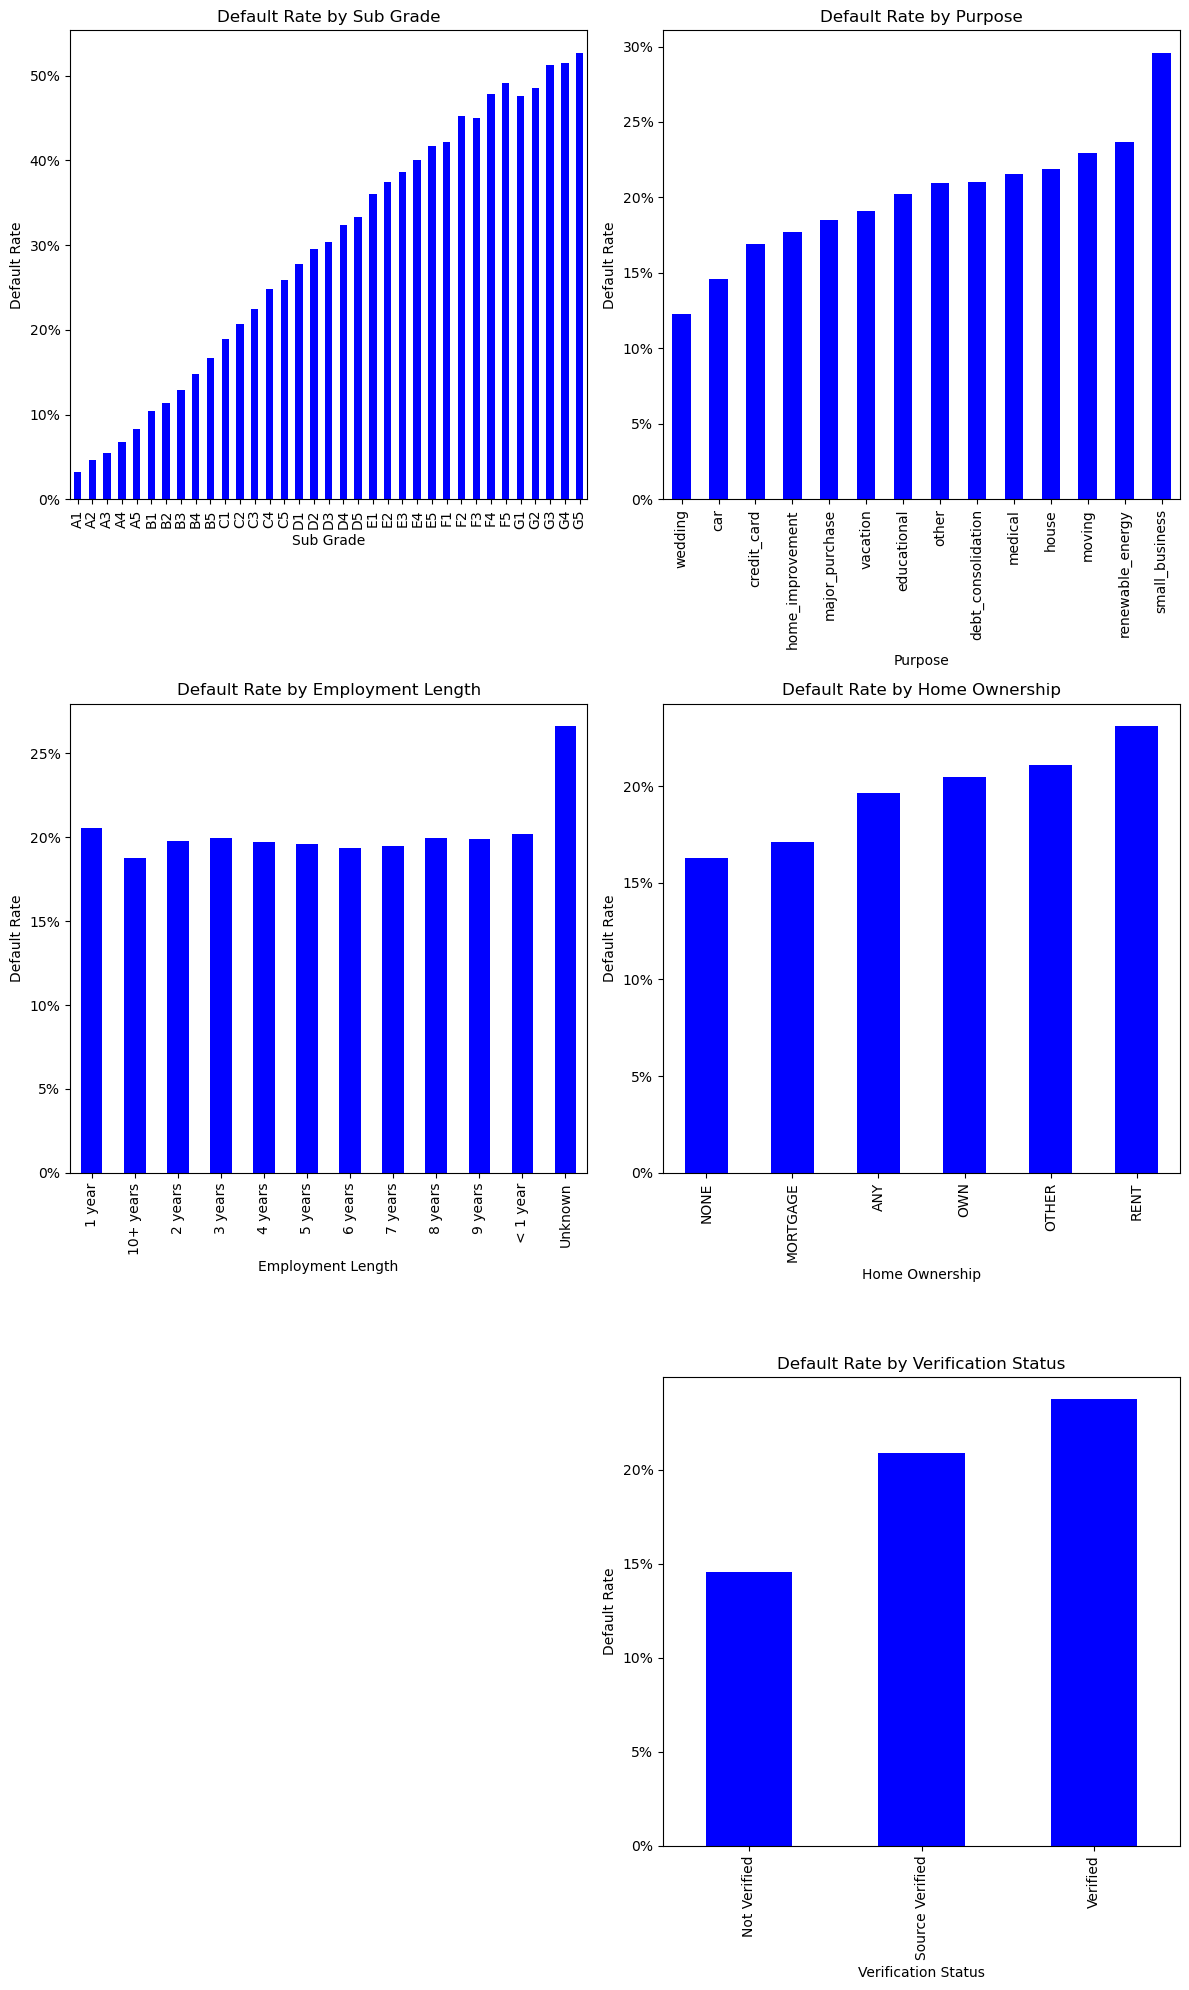

In [146]:
fig, ax = plt.subplots(3, 2, figsize=(12, 20))

# Sub grade
df.groupby('sub_grade')['default'].mean().plot(kind='bar', color='blue', ax=ax[0,0])
ax[0,0].set_title('Default Rate by Sub Grade')
ax[0,0].set_xlabel('Sub Grade')
ax[0,0].set_ylabel('Default Rate')
ax[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Purpose
df.groupby('purpose')['default'].mean().sort_values().plot(kind='bar', color='blue', ax=ax[0,1])
ax[0,1].set_title('Default Rate by Purpose')
ax[0,1].set_xlabel('Purpose')
ax[0,1].set_ylabel('Default Rate')
ax[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Employment length
df.groupby('emp_length')['default'].mean().plot(kind='bar', color='blue', ax=ax[1,0])
ax[1,0].set_title('Default Rate by Employment Length')
ax[1,0].set_xlabel('Employment Length')
ax[1,0].set_ylabel('Default Rate')
ax[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Home ownership
df.groupby('home_ownership')['default'].mean().sort_values().plot(kind='bar', color='blue', ax=ax[1,1])
ax[1,1].set_title('Default Rate by Home Ownership')
ax[1,1].set_xlabel('Home Ownership')
ax[1,1].set_ylabel('Default Rate')
ax[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Home ownership
df.groupby('verification_status')['default'].mean().sort_values().plot(kind='bar', color='blue', ax=ax[2,1])
ax[2,1].set_title('Default Rate by Verification Status')
ax[2,1].set_xlabel('Verification Status')
ax[2,1].set_ylabel('Default Rate')
ax[2,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# Hide the plot not being used
ax[2,0].set_visible(False)

plt.tight_layout()
plt.show()

sub_grade: We see a clear trend with sub_grade as expected, the poorer the grade the higher the default rate.  

purpose: This definitely tells a story, small businesses are the riskiest as you would expect, and there are definitely differences across the different purposes.  

emp_length: There is no real trend across different employment lengths, except from 'Unknown' which is an outlier at around 25% default rate. It was the correct decision to assign a new value to this instead of removing the people that didn't disclose their employment length. It is worth noting that 10+ years is slightly less than average although this is only by around 1%.  

home_ownership: Mortgage holders default much less than those who rent. It is interesting to see that mortgage holders also default less than those who own.  

verification_status: Those without a verified income default considerably less than those with the source verified, and there is an even bigger gap to those with income verified. This is interesting to see and isn't what I would've expected. It could perhaps be due to a small sample size for those without a verified income so I will look into this.

In [147]:
print(df['verification_status'].value_counts())

verification_status
Source Verified    513859
Verified           408676
Not Verified       397572
Name: count, dtype: int64


The sample size is large so this isn't the case. One possibility is that income status was only verified for lenders who seemed risky, so this could be more for risk flagging than a measure of trustworthiness. This could be a great predictive signal.

Now we will look at loan volume and default rate over time. I expect to see a spike in default rates around 2008-09 matching up with the financial crisis

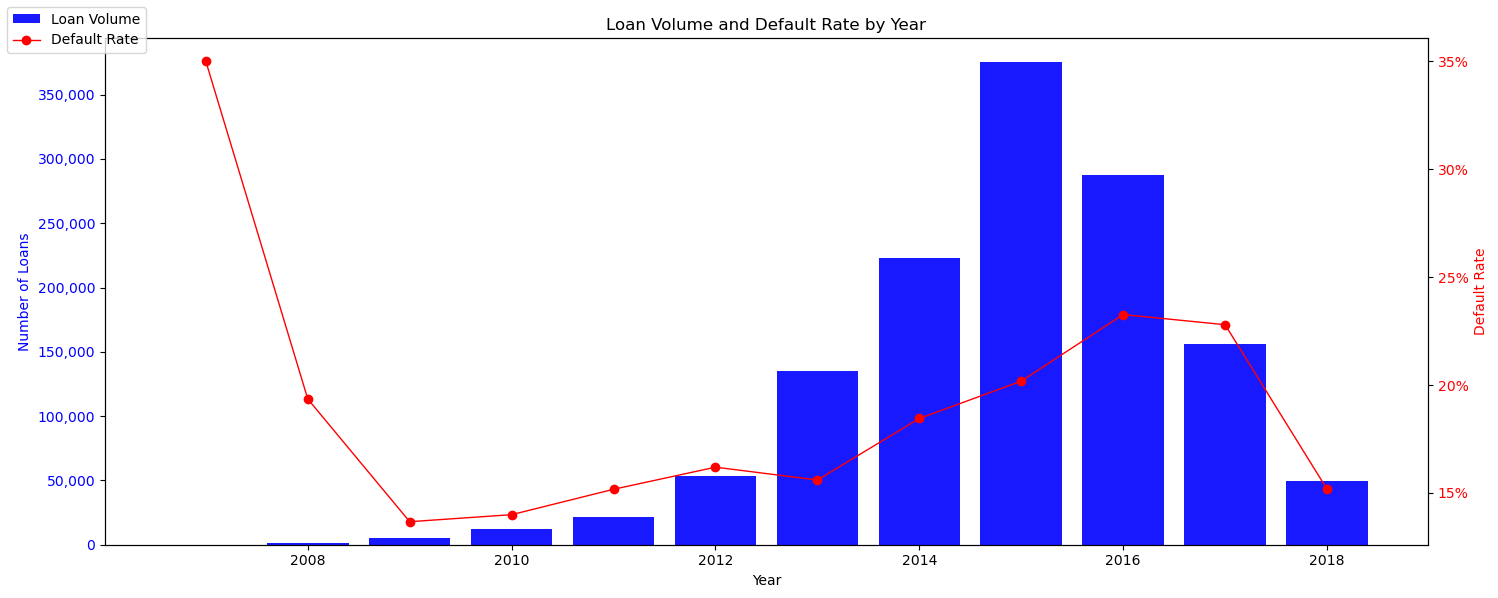

In [148]:
fig, ax_1 = plt.subplots(figsize=(15, 6))

# Calculate yearly stats
year_stats = df.groupby(df['issue_d'].dt.year).agg(
    loan_count=('loan_amnt', 'count'),
    default_rate=('default', 'mean')
).reset_index()

# Bar chart for loan volume on first y axis
ax_1.bar(year_stats['issue_d'], year_stats['loan_count'], color='blue', alpha = 0.9, label='Loan Volume')
ax_1.set_xlabel('Year')
ax_1.set_ylabel('Number of Loans', color='blue')
ax_1.tick_params(axis='y', labelcolor='blue')
ax_1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Line chart for default rate on secondary y axis
ax_2 = ax_1.twinx()
ax_2.plot(year_stats['issue_d'], year_stats['default_rate'], color='red', marker='o', linewidth=1, label='Default Rate')
ax_2.set_ylabel('Default Rate', color='red')
ax_2.tick_params(axis='y', labelcolor='red')
ax_2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.title('Loan Volume and Default Rate by Year')
fig.legend(loc='upper left')
plt.tight_layout()
plt.show()

There is actually not really a spike during the financial crisis. This is perhaps because lending club didn't operate at a high volume. We see a rapid growth from 2007 through to 2015 which reflects the expansion of Lending Club over this time. It is interesting to see the steady increase in default rates from 2009 to 2016. This could represent a loosening in lending criteria to help with their rapid growth. 2007 should be ignored due to the small sample size and 2017/18 need to be carefully interpreted as some loans issued at this time haven't had enough time to default.

In [149]:
print(df.columns.tolist())

['loan_amnt', 'term', 'int_rate', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'mort_acc', 'pub_rec_bankruptcies', 'fico_avg', 'credit_history_months', 'default']


We have 10 more variables to explore

We will look at the remaining numerical variables

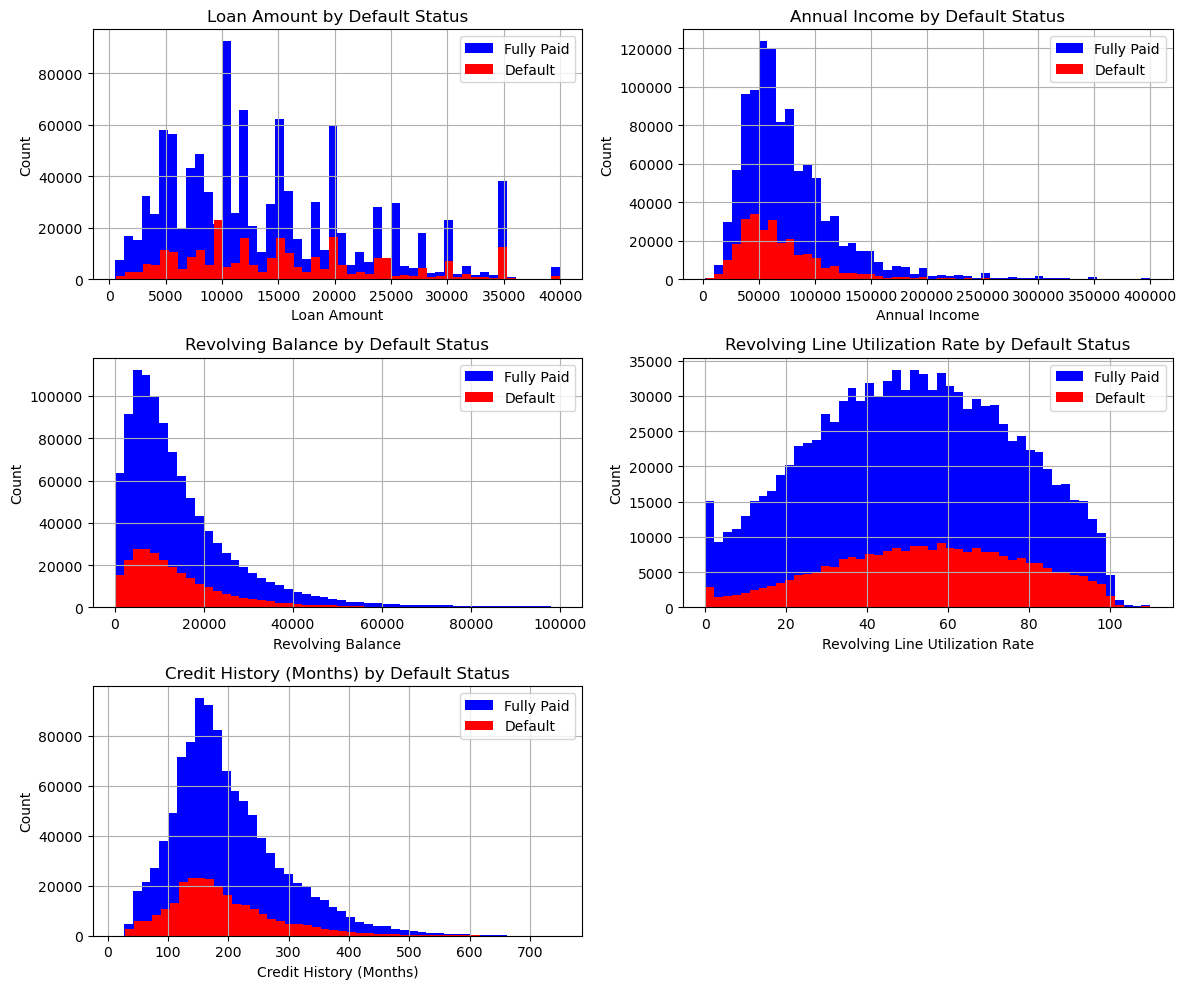

In [150]:
fig, ax = plt.subplots(3, 2, figsize=(12, 10))

# Loan Amount
df[df['default']==0]['loan_amnt'].hist(label='Fully Paid', color='blue', bins=50, ax=ax[0,0])
df[df['default']==1]['loan_amnt'].hist(label='Default', color='red', bins=50, ax=ax[0,0])
ax[0,0].set_title('Loan Amount by Default Status')
ax[0,0].set_xlabel('Loan Amount')
ax[0,0].set_ylabel('Count')
ax[0,0].legend()

# Annual Income
df[(df['default']==0) & (df['annual_inc']<= 400000)]['annual_inc'].hist(label='Fully Paid', color='blue', bins=50, ax=ax[0,1])
df[(df['default']==1) & (df['annual_inc']<= 400000)]['annual_inc'].hist(label='Default', color='red', bins=50, ax=ax[0,1])
ax[0,1].set_title('Annual Income by Default Status')
ax[0,1].set_xlabel('Annual Income')
ax[0,1].set_ylabel('Count')
ax[0,1].legend()

# Revolving Balance
df[(df['default']==0) & (df['revol_bal']<= 100000)]['revol_bal'].hist(label='Fully Paid', color='blue', bins=50, ax=ax[1,0])
df[(df['default']==1) & (df['revol_bal']<= 100000)]['revol_bal'].hist(label='Default', color='red', bins=50, ax=ax[1,0])
ax[1,0].set_title('Revolving Balance by Default Status')
ax[1,0].set_xlabel('Revolving Balance')
ax[1,0].set_ylabel('Count')
ax[1,0].legend()

# Revolving Line Utilization Rate
df[df['default']==0]['revol_util'].clip(upper=110).hist(label='Fully Paid', color='blue', bins=50, ax=ax[1,1])
df[df['default']==1]['revol_util'].clip(upper=110).hist(label='Default', color='red', bins=50, ax=ax[1,1])
ax[1,1].set_title('Revolving Line Utilization Rate by Default Status')
ax[1,1].set_xlabel('Revolving Line Utilization Rate')
ax[1,1].set_ylabel('Count')
ax[1,1].legend()

# Credit History Months
df[df['default']==0]['credit_history_months'].clip(upper=750).hist(label='Fully Paid', color='blue', bins=50, ax=ax[2,0])
df[df['default']==1]['credit_history_months'].clip(upper=750).hist(label='Default', color='red', bins=50, ax=ax[2,0])
ax[2,0].set_title('Credit History (Months) by Default Status')
ax[2,0].set_xlabel('Credit History (Months)')
ax[2,0].set_ylabel('Count')
ax[2,0].legend()

ax[2,1].set_visible(False)
plt.tight_layout()
plt.show()

loan_amnt: The distributions heavily overlap which shows that on its own, this isn't a good predictor for default status. While irrelevant to the model, it is interesting tto see the spikes every 5,000. This suggests that loans are typically offered at fixed increments.  

annual_inc: We see a clear leftward shift which reflects the expected income distribution, although this shift is more pronounced for defaulters, with a much higher concentration being of lower income. This is also reflected in the below graph of higher income individuals where we see there is only a small proportion of defaulters.  

revol_bal: The distributions heavily overlap again, although in the below graph which maps the more extreme outliers, we do see that there appears to be a slightly lower default rate here, albeit it is still a weak signal.  

revol_util: This is one of the more interesting results. Defaulters are clearly more prominent at higher utilization rates. While non defaulters are evenly spread out, there is a clear rightward shift for defaulters. 

credit_history_months: Both of these distributions appear very similar, although there is a slightly stronger leftward shift for defaulters, so as expected there is more risk when dealing with those without a long credit history.

Lets also look at the outliers in annual_inc, revol_bal to see if these behave differently

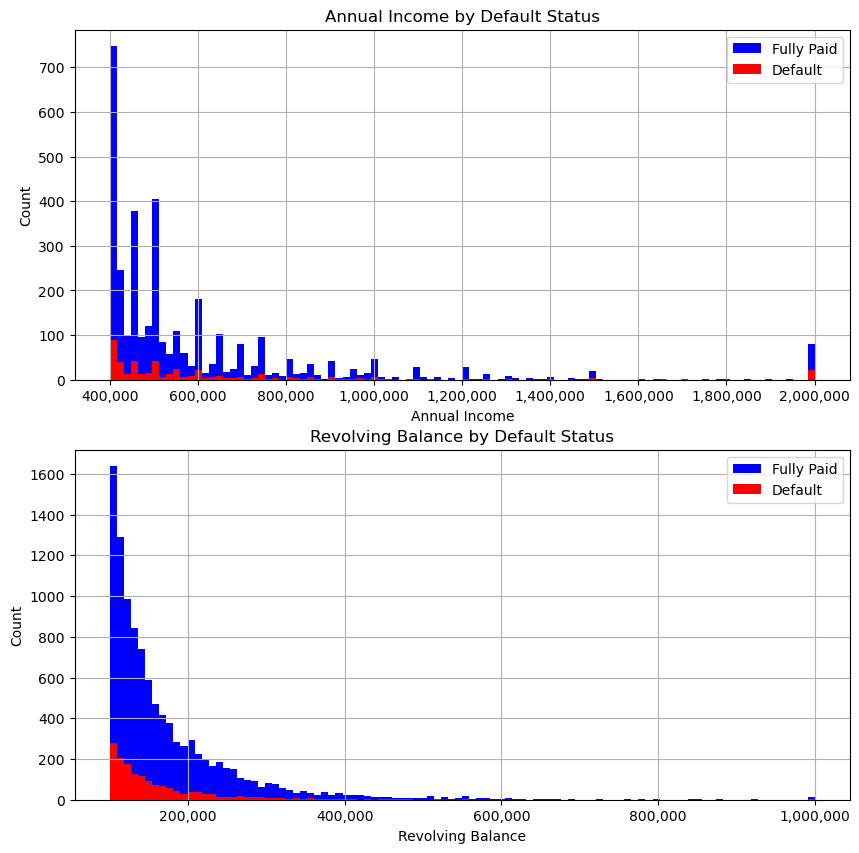

In [151]:
fig, ax = plt.subplots(2, figsize=(10, 10))

# Loan Amount
df[(df['default']==0) & (df['annual_inc'] >= 400000)]['annual_inc'].clip(upper=2000000).hist(label='Fully Paid', color='blue', bins=100, ax=ax[0])
df[(df['default']==1) & (df['annual_inc'] >= 400000)]['annual_inc'].clip(upper=2000000).hist(label='Default', color='red', bins=100, ax=ax[0])
ax[0].set_title('Annual Income by Default Status')
ax[0].set_xlabel('Annual Income')
ax[0].set_ylabel('Count')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax[0].legend()

# Annual Income
df[(df['default']==0) & (df['revol_bal'] >= 100000)]['revol_bal'].clip(upper=1000000).hist(label='Fully Paid', color='blue', bins=100, ax=ax[1])
df[(df['default']==1) & (df['revol_bal'] >= 100000)]['revol_bal'].clip(upper=1000000).hist(label='Default', color='red', bins=100, ax=ax[1])
ax[1].set_title('Revolving Balance by Default Status')
ax[1].set_xlabel('Revolving Balance')
ax[1].set_ylabel('Count')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax[1].legend()

Those with higher income seem to default less than average, although there isn't a huge sample size.  

The same also goes for revolving balance, there is a leftward shift in the previous graph and we see this here also, those with a higher revolving balance default a lot less. This is expected, they take out more loans so pay them back more often.

We look at the remaining #Not categorical# variables:

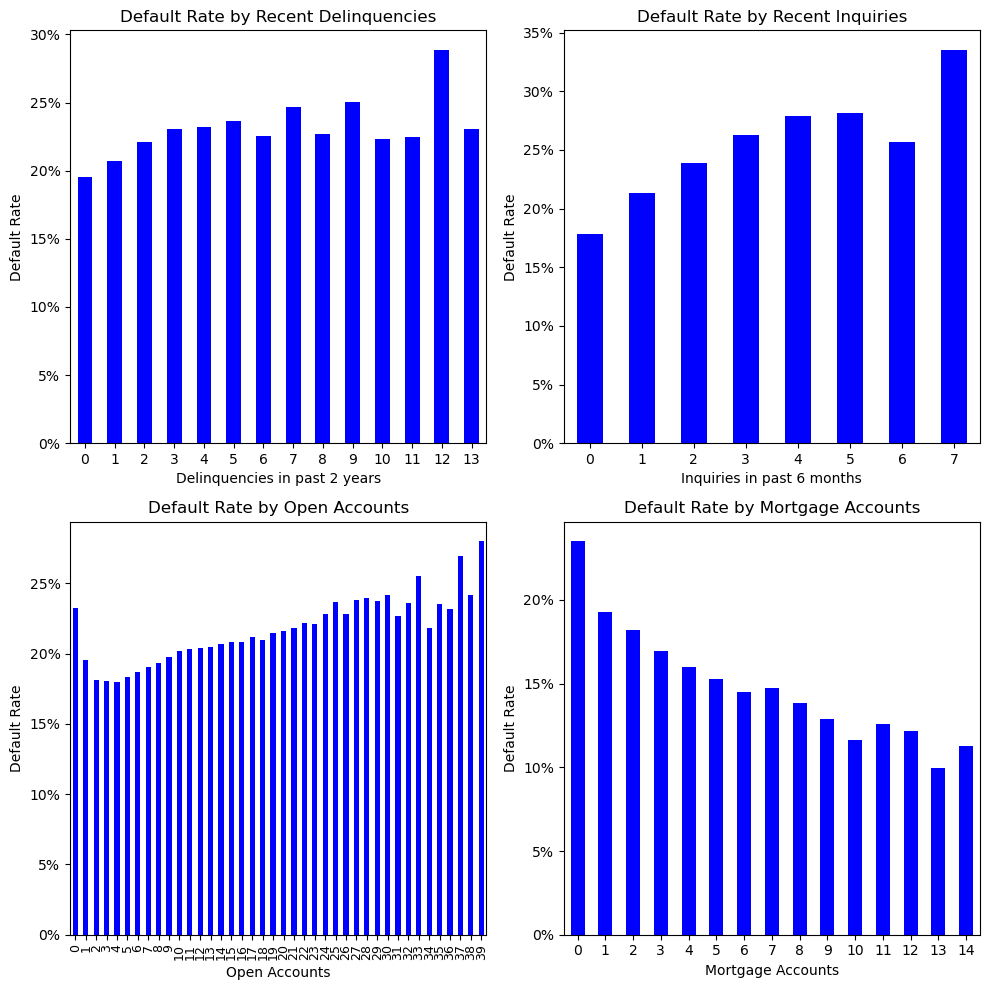

In [152]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

# Delinquencies
df.groupby('delinq_2yrs')['default'].mean().head(14).plot(kind='bar', color='blue', ax=ax[0,0])
ax[0,0].set_title('Default Rate by Recent Delinquencies')
ax[0,0].set_xlabel('Delinquencies in past 2 years')
ax[0,0].set_ylabel('Default Rate')
ax[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax[0,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
ax[0,0].tick_params(axis='x', rotation=0)

# Inquiries
df.groupby('inq_last_6mths')['default'].mean().head(8).plot(kind='bar', color='blue', ax=ax[0,1])
ax[0,1].set_title('Default Rate by Recent Inquiries')
ax[0,1].set_xlabel('Inquiries in past 6 months')
ax[0,1].set_ylabel('Default Rate')
ax[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax[0,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
ax[0,1].tick_params(axis='x', rotation=0)

# Open Accounts
df.groupby('open_acc')['default'].mean().head(40).plot(kind='bar', color='blue', ax=ax[1,0])
ax[1,0].set_title('Default Rate by Open Accounts')
ax[1,0].set_xlabel('Open Accounts')
ax[1,0].set_ylabel('Default Rate')
ax[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax[1,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
ax[1,0].tick_params(axis='x', labelsize=9)

# Mortgage Accounts
df.groupby('mort_acc')['default'].mean().head(15).plot(kind='bar', color='blue', ax=ax[1,1])
ax[1,1].set_title('Default Rate by Mortgage Accounts')
ax[1,1].set_xlabel('Mortgage Accounts')
ax[1,1].set_ylabel('Default Rate')
ax[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax[1,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'))
ax[1,1].tick_params(axis='x', rotation=0)


plt.tight_layout()
plt.show()

delinq_2yrs: While those with no recent delinquencies have the lowest default rate, it is only slightly lower and there is no real noticeable increase as delinquencies increase. 
  
inq_last_6mths: Recent inquiries on the other hand sees a much larger correlation with default rate. No recent inquiries has the lowest default rate and it consistently increases as the number of recent inquiries increases. This suggests that recent inquiries could be a strong predictor for default rate.  
  
open_acc: This is more interesting in that it is slightly U shaped at the start, although on closer inspection I believe this makes sense. There is a smaller sample size for those with less accounts - particularly only 1 or 2 - and people with less accounts will have a smaller average credit history in months which as discovered earlier correlates with a higher default rate. After the downward trend at the start, there is a steady increase as the number of open accounts increases, a definite upward trend.  
  
mort_acc: We see the opposite trend here compared the total open accounts. There is a clear downward trend which appears to start to even out as it reaches higher values (9+). This makes sense intuitively as those who already have a mortgage will have already been approved elsewhere, meaning they have been deemed trustworthy.

In [153]:
print(df['open_acc'].value_counts().sort_index())

open_acc
1.0       413
2.0      4534
3.0     15743
4.0     36379
5.0     60453
        ...  
82.0        1
84.0        1
86.0        1
88.0        1
90.0        1
Name: count, Length: 83, dtype: int64


Now we prepare the data for modelling

In [154]:
# Issue date isn't known when they apply. We create a new dataset df_model so we can later train on 07-14 and test on 15-18
df_model = df.drop(columns='issue_d')

In [155]:
print(df_model.select_dtypes(include='object').columns.tolist())

['term', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose']


There is no one solution that is best for all of these so we will split them

In [156]:
#term 
#there are 2 options here - 36 months and 60 months
df_model['term'] = df_model['term'].str.strip()
df_model['term'] = df_model.term.map({'36 months': 36, '60 months': 60})

#sub_grade has a natural order from A1 through to G5
sub_grade_order = ['A1', 'A2', 'A3', 'A4', 'A5', 
                   'B1', 'B2', 'B3', 'B4', 'B5', 
                   'C1', 'C2', 'C3', 'C4', 'C5', 
                   'D1', 'D2', 'D3', 'D4', 'D5',
                   'E1', 'E2', 'E3', 'E4', 'E5',
                   'F1', 'F2', 'F3', 'F4', 'F5', 
                   'G1', 'G2', 'G3', 'G4', 'G5'] 
df_model['sub_grade'] = df_model.sub_grade.map({grade: i+1 for i, grade in enumerate(sub_grade_order)})

#emp_length also has a clear order. 'Unknown' will be set as -1 since this was shown to have a more negative impact.
emp_length_order = {
    'Unknown': -1, 
    '< 1 year': 0, 
    '1 year': 1, 
    '2 years': 2, 
    '3 years': 3, 
    '4 years': 4, 
    '5 years': 5, 
    '6 years': 6, 
    '7 years': 7, 
    '8 years': 8, 
    '9 years': 9, 
    '10+ years': 10
}
df_model['emp_length'] = df_model.emp_length.map(emp_length_order)

#The rest don't have a real order
dummies = ['home_ownership', 'verification_status', 'purpose']
df_model = pd.get_dummies(df_model, columns=dummies, drop_first=True)

print(df_model.select_dtypes(include='object').columns.tolist())

[]


In [157]:
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

Series([], dtype: int64)


In [158]:
print(df_model.head())

   loan_amnt  term  int_rate  sub_grade  emp_length  annual_inc    dti  \
0     3600.0    36     13.99         14          10     55000.0   5.91   
1    24700.0    36     11.99         11          10     65000.0  16.06   
4    10400.0    60     22.45         26           3    104433.0  25.37   
5    11950.0    36     13.44         13           4     34000.0  10.20   
6    20000.0    36      9.17          7          10    180000.0  14.67   

   delinq_2yrs  inq_last_6mths  open_acc  pub_rec  revol_bal  revol_util  \
0          0.0             1.0       7.0      0.0     2765.0        29.7   
1          1.0             4.0      22.0      0.0    21470.0        19.2   
4          1.0             3.0      12.0      0.0    21929.0        64.5   
5          0.0             0.0       5.0      0.0     8822.0        68.4   
6          0.0             0.0      12.0      0.0    87329.0        84.5   

   mort_acc  pub_rec_bankruptcies  ...  verification_status_Source Verified  \
0       1.0        

In [159]:
#Check for duplicate rows
print(f'Duplicate rows: {df_model.duplicated().sum()}')

Duplicate rows: 0


In [160]:
#Now split the explanatory variables and response variable
X = df_model.drop(columns=['default'])
y = df_model['default']

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 92, stratify = y)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True) * 100)
print(y_test.value_counts(normalize=True) * 100)

pickle.dump((X_train, X_test, y_train, y_test), open('train_test_split.pkl', 'wb'))

(1056085, 37)
(264022, 37)
default
0    80.114574
1    19.885426
Name: proportion, dtype: float64
default
0    80.114536
1    19.885464
Name: proportion, dtype: float64


Since there are columns like annual_inc that can be 200,000+ and others like dti which are less than 100, if the model is built without scaling this the model will weigh the larger variables.

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#We keep X_train and X_test as we will use these for the XGBoost model
pickle.dump((X_train_scaled, X_test_scaled, _, _), open('scaled_data.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

Logistic Regression Results
----------------------------
              precision    recall  f1-score   support

           0       0.81      0.98      0.89    211520
           1       0.53      0.08      0.15     52502

    accuracy                           0.80    264022
   macro avg       0.67      0.53      0.52    264022
weighted avg       0.76      0.80      0.74    264022

ROC-AUC: 0.7096


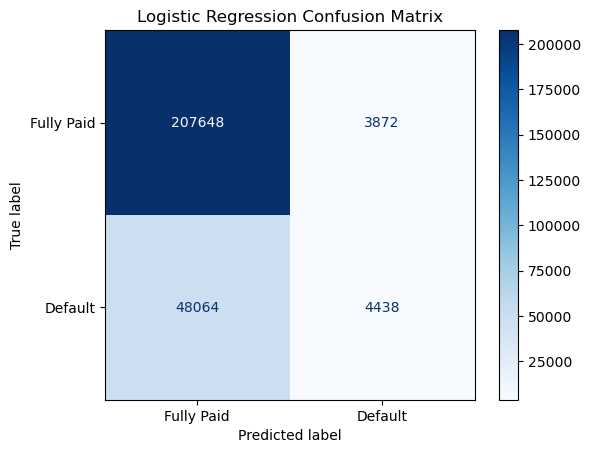

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import pickle

#train model
lr = LogisticRegression(max_iter=1000, random_state=92)
lr.fit(X_train_scaled, y_train)

#prediction
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

#evaluation
print('Logistic Regression Results')
print('----------------------------')
print(classification_report(y_test, y_pred_lr))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}')

#confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fully Paid', 'Default'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

pickle.dump(lr, open('lr.pkl', 'wb'))

The ROC AUC of 0.7096 is solid although can definitely be improved in other models. However there is a big problem in that the recall score for defaulters is only 0.08. This means that 92% of defaulters are predicted as fully paid this shows that the model has learned that predicting 'Fully Paid' most of the time gives it an 80% accuracy. The 48061 defaulters missed is something that need to be fixed as tis could lead to large losses for the bank. We will make a new logistic regression model that penalises missed defaults more heavily.

Logistic Regression Results
----------------------------
              precision    recall  f1-score   support

           0       0.88      0.66      0.76    211520
           1       0.32      0.64      0.43     52502

    accuracy                           0.66    264022
   macro avg       0.60      0.65      0.59    264022
weighted avg       0.77      0.66      0.69    264022

ROC-AUC: 0.7098


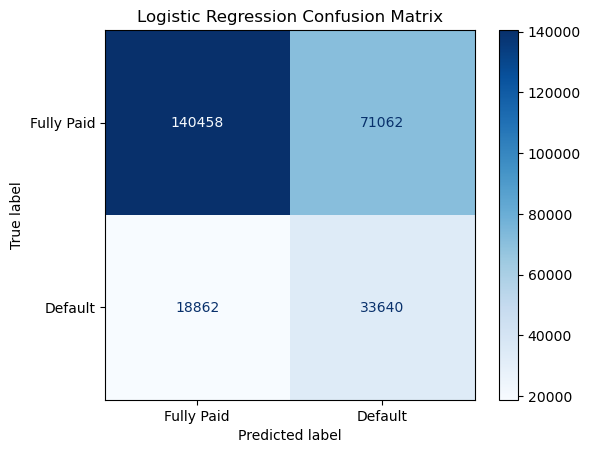

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

#train model
lr_balanced = LogisticRegression(max_iter=1000, random_state=92, class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)

#prediction
y_pred_lr_balanced = lr_balanced.predict(X_test_scaled)
y_prob_lr_balanced = lr_balanced.predict_proba(X_test_scaled)[:, 1]

#evaluation
print('Logistic Regression Results')
print('----------------------------')
print(classification_report(y_test, y_pred_lr_balanced))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_lr_balanced):.4f}')

#confusion matrix
cm = confusion_matrix(y_test, y_pred_lr_balanced)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fully Paid', 'Default'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

pickle.dump(lr_balanced, open('lr_balanced.pkl', 'wb'))

It is interesting to see that this has a near identical ROC-AUC score of 0.7098 compared to the previous models 0.7096. This suggests that the overall discriminatory power of the model hasn't really changed but instead the breakdown of its predictions. Looking at defaulters specifically, recall has increased from 8% to 64%, while precision has decreased from 53% to 32%. A lot more defaulters are caught but this also leads to non-defaulters being incorrectly predicted as defaulters. The overall accuracy decreases as defauly is being predicted more often, but this means that there are now only 18897 defaulters missed.  

This means that the model of choice should be based on the level of risk the lender is willing to take on, the first model misses a lot of defaults but also rarely falsely accuses customers of being defaulters, while the second, balanced model catches much more defaulters but also falsely accuses a lot of customers of being defaulters.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


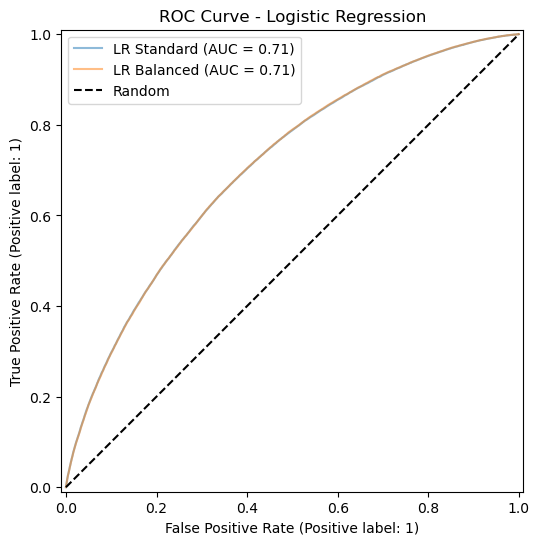

In [71]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, alpha = 0.5, name='LR Standard', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_lr_balanced, alpha = 0.5, name='LR Balanced', ax=ax)
ax.plot([0,1], [0,1], 'k--', label='Random')
ax.legend()
plt.title('ROC Curve - Logistic Regression')
plt.show()

Both curves are practically identical, confirming the addition of class weighting doesn't change the discriminatory power of the model. The curves rise steeply before flattening out, siggesting they are good at spotting the obvious defaulters but struggle more when it comes to the borderline cases.

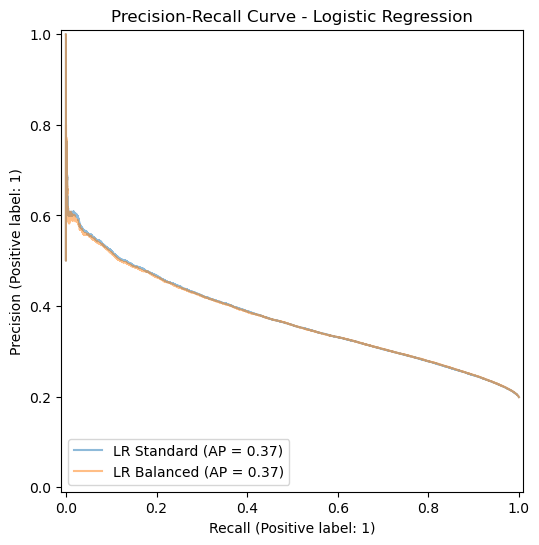

In [72]:
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(8, 6))
PrecisionRecallDisplay.from_predictions(y_test, y_prob_lr, alpha = 0.5, name='LR Standard', ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, y_prob_lr_balanced, alpha = 0.5, name='LR Balanced', ax=ax)
plt.title('Precision-Recall Curve - Logistic Regression')
plt.show()

Both curves are very similar - nothing proper to take note of.

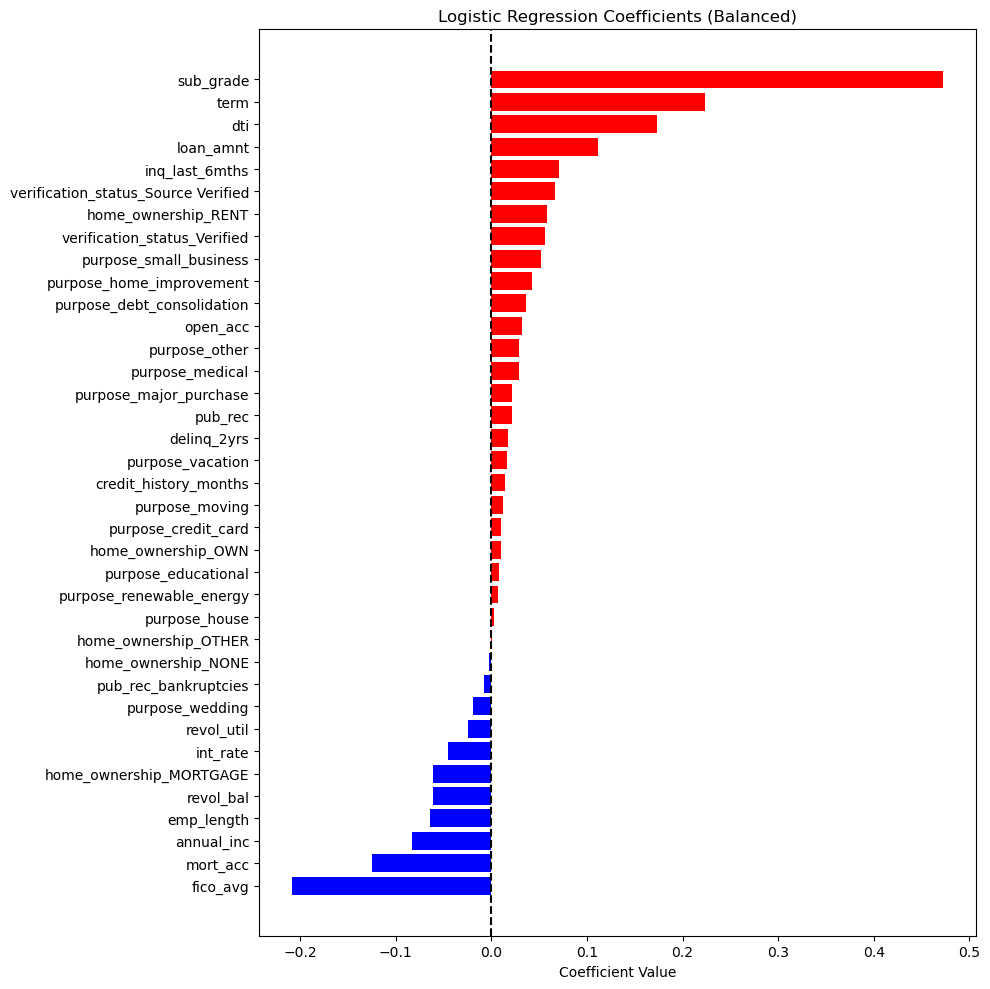

In [73]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_balanced.coef_[0]
}).sort_values('coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['red' if c > 0 else 'blue' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.title('Logistic Regression Coefficients (Balanced)')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

There is a lot to talk about from this graph.  
sub_grade is the strongest positive predictor of default, confirming the validity of LendingClub's internal grading system. fico_avg is the strongest negative predictor, consistent with its role as the primary measure of creditworthiness. It is interesting to see that int_rate shows a negative coefficient despite its strong positive correlation with default in the univariate analysis. This reflects multicollinearity with sub_grade, as once grade is controlled for, the residual variation in interest rate carries different information.

Now time for a regularised logistic regression model.  
We keep class weight = balanced as this is better at predicting defaulters, despite overall accuracy not being too different.

L1 done
L1 Regularised Logistic Regression
------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.66      0.76    211520
           1       0.32      0.64      0.43     52502

    accuracy                           0.66    264022
   macro avg       0.60      0.65      0.59    264022
weighted avg       0.77      0.66      0.69    264022

ROC-AUC: 0.7098


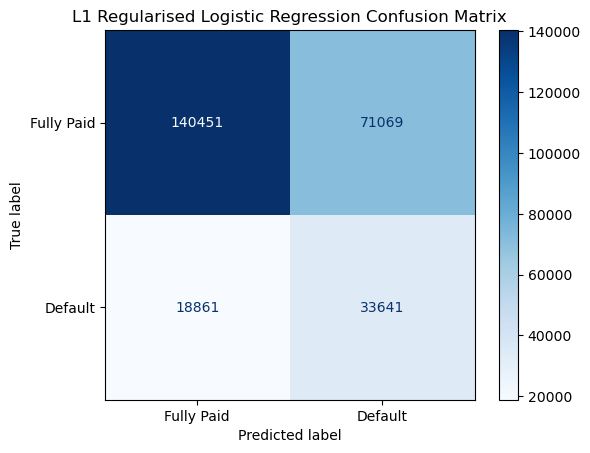

Features zeroed out by L1:
Empty DataFrame
Columns: [feature, coefficient]
Index: []


In [75]:
from sklearn.linear_model import LogisticRegression

# L1 Regularisation (Lasso)
lr_l1 = LogisticRegression(penalty='l1', class_weight='balanced', max_iter=1000, random_state=92, solver='liblinear', C=1.0)
lr_l1.fit(X_train_scaled, y_train)
pickle.dump(lr_l1, open('lr_l1.pkl', 'wb'))
print('L1 done')

y_pred_l1 = lr_l1.predict(X_test_scaled)
y_prob_l1 = lr_l1.predict_proba(X_test_scaled)[:, 1]

print('L1 Regularised Logistic Regression')
print('------------------------------------')
print(classification_report(y_test, y_pred_l1))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_l1):.4f}')

cm_l1 = confusion_matrix(y_test, y_pred_l1)
disp_l1 = ConfusionMatrixDisplay(confusion_matrix=cm_l1, display_labels=['Fully Paid', 'Default'])
disp_l1.plot(cmap='Blues')
plt.title('L1 Regularised Logistic Regression Confusion Matrix')
plt.show()
# Check which features L1 zeroed out
zero_coef = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': lr_l1.coef_[0]
})
print('Features zeroed out by L1:')
print(zero_coef[zero_coef['coefficient'] == 0])

L2 done
L2 Regularised Logistic Regression
------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.66      0.76    211520
           1       0.32      0.64      0.43     52502

    accuracy                           0.66    264022
   macro avg       0.60      0.65      0.59    264022
weighted avg       0.77      0.66      0.69    264022

ROC-AUC: 0.7098


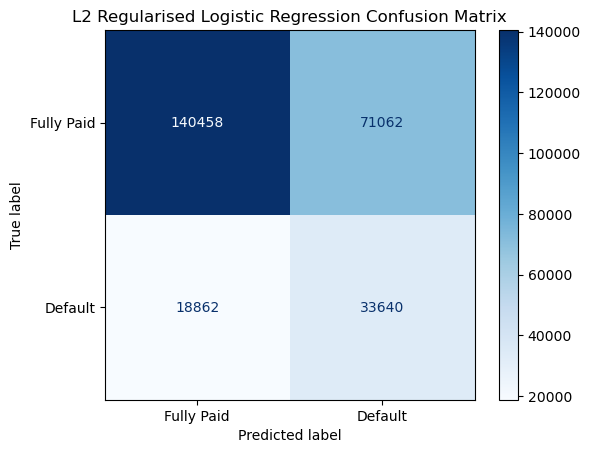

In [76]:
# L2 Regularisation (Ridge)
lr_l2 = LogisticRegression(penalty='l2', class_weight='balanced', max_iter=1000, random_state=92, C=1.0)
lr_l2.fit(X_train_scaled, y_train)
pickle.dump(lr_l2, open('lr_l2.pkl', 'wb'))
print('L2 done')

y_pred_l2 = lr_l2.predict(X_test_scaled)
y_prob_l2 = lr_l2.predict_proba(X_test_scaled)[:, 1]

print('L2 Regularised Logistic Regression')
print('------------------------------------')
print(classification_report(y_test, y_pred_l2))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_l2):.4f}')

cm_l2 = confusion_matrix(y_test, y_pred_l2)
disp_l2 = ConfusionMatrixDisplay(confusion_matrix=cm_l2, display_labels=['Fully Paid', 'Default'])
disp_l2.plot(cmap='Blues')
plt.title('L2 Regularised Logistic Regression Confusion Matrix')
plt.show()



L1 done
Optimal C: 1291.5496650148827
L1 Regularised Logistic Regression
------------------------------------
              precision    recall  f1-score   support

           0       0.88      0.66      0.76    211520
           1       0.32      0.64      0.43     52502

    accuracy                           0.66    264022
   macro avg       0.60      0.65      0.59    264022
weighted avg       0.77      0.66      0.69    264022

ROC-AUC: 0.7098


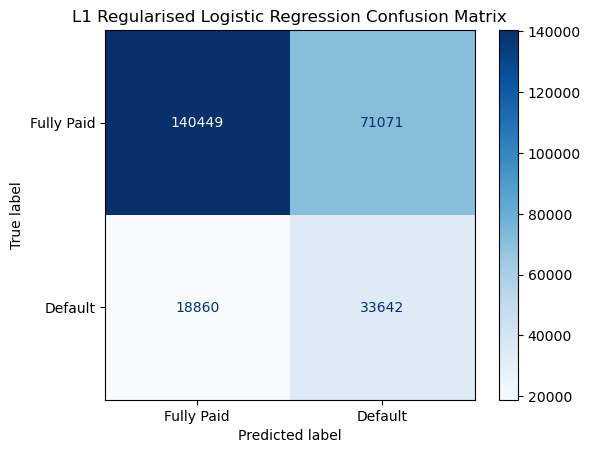

In [78]:
# L1 Regularisation (Lasso)
from sklearn.linear_model import LogisticRegressionCV
lr_l1_cv = LogisticRegressionCV(cv=5, penalty='l1', class_weight='balanced', max_iter=1000, random_state=92, solver='liblinear')
lr_l1_cv.fit(X_train_scaled, y_train)
pickle.dump(lr_l1_cv, open('lr_l1_cv.pkl', 'wb'))
print('L1 done')

y_pred_l1 = lr_l1_cv.predict(X_test_scaled)
y_prob_l1 = lr_l1_cv.predict_proba(X_test_scaled)[:, 1]
print(f'Optimal C: {lr_l1_cv.C_[0]}')

print('L1 Regularised Logistic Regression')
print('------------------------------------')
print(classification_report(y_test, y_pred_l1))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_l1):.4f}')

cm_l1 = confusion_matrix(y_test, y_pred_l1)
disp_l1 = ConfusionMatrixDisplay(confusion_matrix=cm_l1, display_labels=['Fully Paid', 'Default'])
disp_l1.plot(cmap='Blues')
plt.title('L1 Regularised Logistic Regression Confusion Matrix')
plt.show()

Comparing this to using C=1 gives no noticeable difference, suggesting that there is no real overfitting and therefore regularisation is unneccesary. For this reason I will not plot graphs of this as they will be identical to the first logistic regression model

In [69]:
pickle.dump(lr_l1_cv, open('lr_l1_cv.pkl', 'wb'))

Now the XGBoost model

XGBoost done
XGBoost Results
----------------
              precision    recall  f1-score   support

           0       0.89      0.63      0.74    211520
           1       0.31      0.68      0.43     52502

    accuracy                           0.64    264022
   macro avg       0.60      0.66      0.58    264022
weighted avg       0.77      0.64      0.68    264022

ROC-AUC: 0.7147


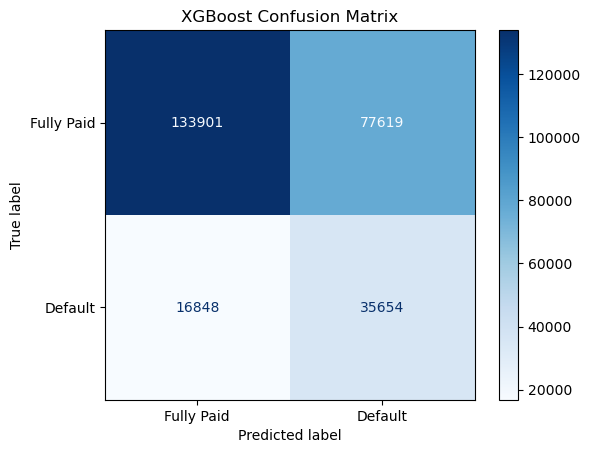

In [62]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=50, # Can change these another time
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=92,
    n_jobs=-1,
    eval_metric='auc'
)

xgb.fit(X_train, y_train)
pickle.dump(xgb, open('xgb.pkl', 'wb'))
print('XGBoost done')

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print('XGBoost Results')
print('----------------')
print(classification_report(y_test, y_pred_xgb))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}')

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Fully Paid', 'Default'])
disp_xgb.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.show()

This XGBoost model sees a noticeable improvement compared to the regression models. The ROC-AUC is almost 0.005 higher along with the recall increasing by 0.04. It does see a slightly lower precision since it incorrectly predicts a higher proportion of non-defaulters as defaulters. This tradeoff is interesting and the model choice would depend on the risk willingness of the lender. They will avoid more of the defaulters, but it also means they will miss out on a lot of good customers

In [63]:
#Try optimisation
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
import pickle

# base model
xgb = XGBClassifier(
    random_state=92,
    n_jobs=-1,
    eval_metric='auc'
)

# parameter space
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'scale_pos_weight': [1, len(y_train[y_train==0]) / len(y_train[y_train==1])]
}

# randomized search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,              # number of combinations to try
    scoring='roc_auc',
    cv=5,
    verbose=1,
    random_state=92,
    n_jobs=-1
)

# fit search
random_search.fit(X_train, y_train)

# best model
best_xgb = random_search.best_estimator_

print("Best parameters:")
print(random_search.best_params_)

# predictions
y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# evaluation
print('XGBoost Results')
print('----------------')
print(classification_report(y_test, y_pred_xgb))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters:
{'subsample': 0.8, 'scale_pos_weight': 4.028808563524073, 'n_estimators': 300, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}
XGBoost Results
----------------
              precision    recall  f1-score   support

           0       0.89      0.65      0.75    211520
           1       0.33      0.67      0.44     52502

    accuracy                           0.66    264022
   macro avg       0.61      0.66      0.60    264022
weighted avg       0.78      0.66      0.69    264022

ROC-AUC: 0.7248


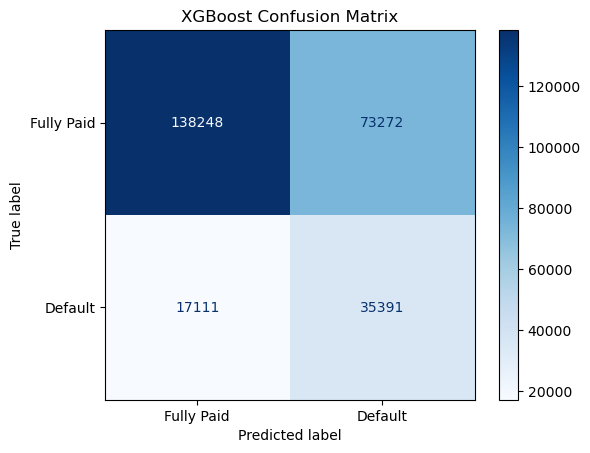

In [82]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Fully Paid', 'Default'])
disp_xgb.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.show()
pickle.dump(best_xgb, open('xgb_best.pkl', 'wb'))

The optimisation here plays a huge part in improving the model. The ROC-AUC increases by 0.01, along with higher precision and f1-score than any of the other models. The recall decreases slightly compared to the original XGBoost model but this is because it catches about 250 less defaulters. The important thing to note is that it predicts about 5000 less defaulters so only missing 250 of this population shows that it is accurate in its predictions. It also allows it to have 5000 more non-defaulters being accepted for the loan.

I start with a feature importance plot for both XGBoost models

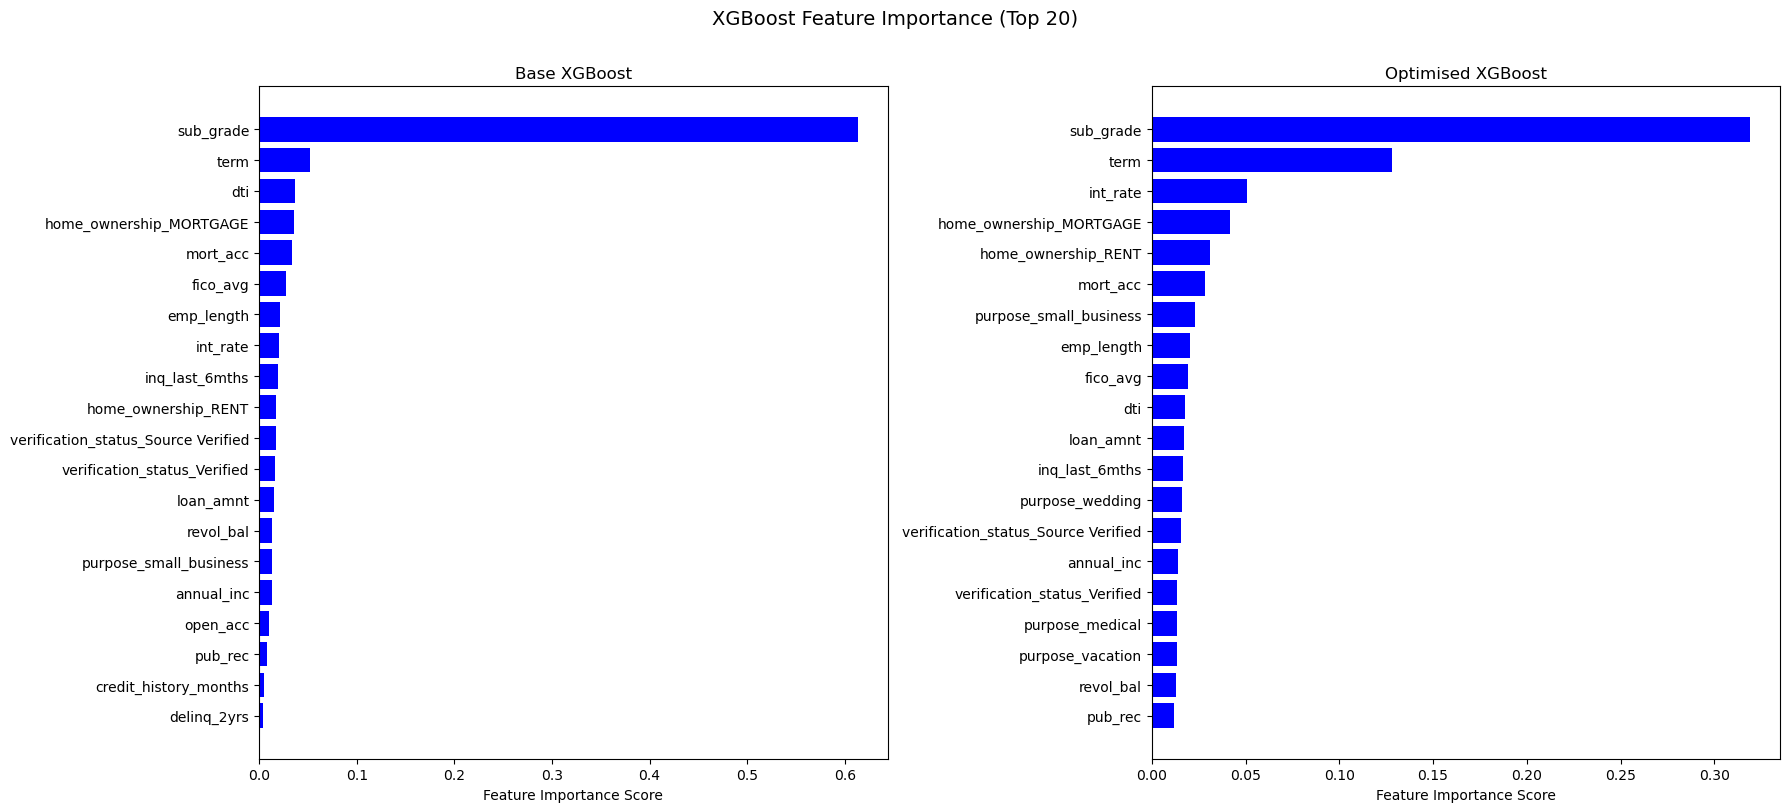

In [85]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

models = [
    (xgb, 'Base XGBoost'),
    (best_xgb, 'Optimised XGBoost')
]

for i in range(len(models)):
    model = models[i][0]
    title = models[i][1]
    ax = axes[i]
    
    # Pair importances with names
    importances = model.feature_importances_
    feature_names = X_train.columns
    
    # Sort by ascending order
    indices = np.argsort(importances)[::-1][:20]
    
    ax.barh(
        y=feature_names[indices][::-1],
        width=importances[indices][::-1],
        color='blue'
    )
    ax.set_title(title)
    ax.set_xlabel('Feature Importance Score')

plt.suptitle('XGBoost Feature Importance (Top 20)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

There is a big difference between the feature importances of the two models.  
sub_grade dominates both, especially in the base model with more then 0.6 of total importance. This is expected as it has a shallower depth than the optimised model, so it relies more heavily on the strongest feature. It drops to just over 0.3 in the optimised model, showing that it is still a very important feature although it allows more importance to other features as well, making it more balanced. sub_grade is the feature that I would expect to have the greatest importance, as it is LendingClubs own risk rating, the poorer grades are the ones they would expect to default more.  
The base model doesn't see int_rate as very important, however it moves to the third most important feature in the optimised model. This is interesting to see as int_rate and sub_grade are correlated, but the deeper model is finding that it carries additional information which supports my earlier decision to keep it.  
I would expect fico_avg to be a very important feature, but it is quite irrelevant to both, especially the deeper optimised model. It is the industry standard risk score but it is possible that sub_grade already captures this risk, and then the optimised model also has int_rate capturing some of this also.  
In both models, purpose_small_business has the greatest importance of all purposes, which makes sense as this has the highest default rate. However, we don't see the same trend with home_ownership, mortgage is the most important feature in both models but this has the second lowes default rate of all home_ownership types.  
It is good that the optimised model is more balanced with higher importance to more features, which makes the model more robust and not too reliant on just one feature.

Now ROC curves

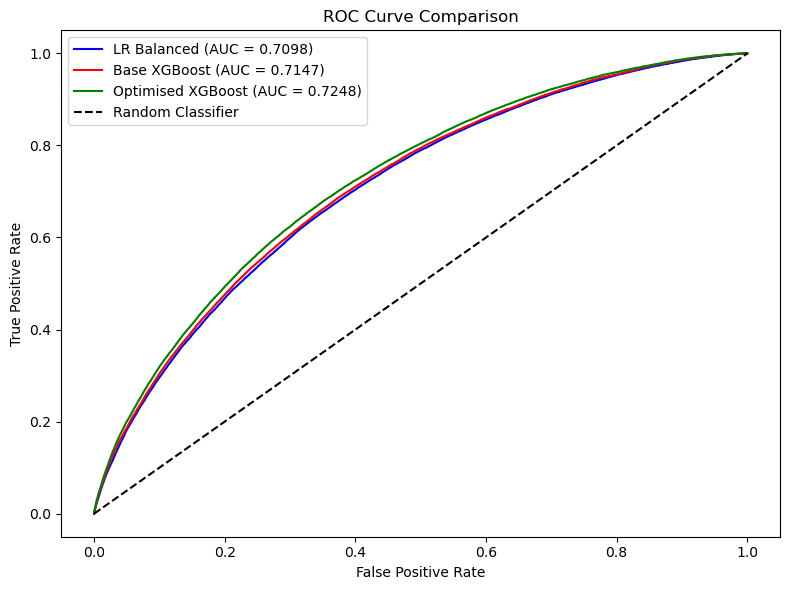

In [90]:
fig, ax = plt.subplots(figsize=(8, 6))
# Compare with logistic regression curve
y_probs = [y_prob_lr_balanced, y_prob_xgb, y_prob_best_xgb]
labels = ['LR Balanced', 'Base XGBoost', 'Optimised XGBoost']
colours = ['blue', 'red', 'green']

for i in range(len(y_probs)):
    false_pos_rate, true_pos_rate, _ = roc_curve(y_test, y_probs[i])
    auc = roc_auc_score(y_test, y_probs[i])
    ax.plot(false_pos_rate, true_pos_rate, label=f'{labels[i]} (AUC = {auc:.4f})', color=colours[i])

# Diagonal line representing a random classifier
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

By comparing these, we see that the Optimised model is actually considerably better, while the Base model is similar to the LR model. There is a big difference in the first half, where there is a lower false positive rate. This is the most important part for a lender as they wouldn't want a high false positive rate.

Now we do a random forest, I don't expect this to be any better than the optimised XGBoost but it will be interesting to see as it uses a different method.

Random Forest done
Random Forest Results
---------------------
              precision    recall  f1-score   support

           0       0.89      0.61      0.73    211520
           1       0.31      0.69      0.42     52502

    accuracy                           0.63    264022
   macro avg       0.60      0.65      0.57    264022
weighted avg       0.77      0.63      0.67    264022

ROC-AUC: 0.7106


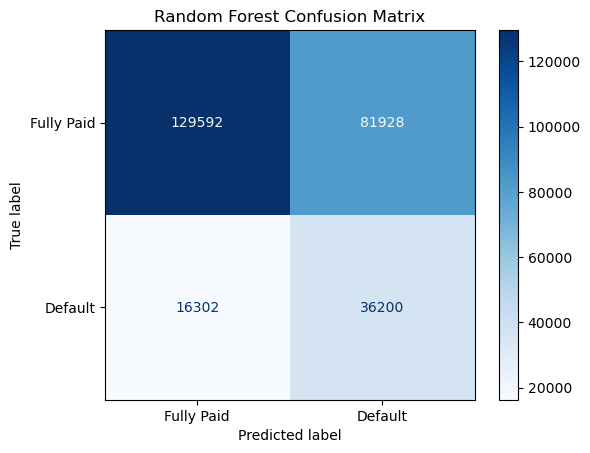

In [92]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100, # trains on all trees so don't need as many as optimised XGBoost
    max_depth=8,
    class_weight='balanced',  # equivalent to scale_pos_weight in XGBoost
    random_state=92,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pickle.dump(rf, open('rf.pkl', 'wb'))
print('Random Forest done')

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('Random Forest Results')
print('---------------------')
print(classification_report(y_test, y_pred_rf))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Fully Paid', 'Default'])
disp_rf.plot(cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.show()

This sits between the LR models and the Base XGBoost model, which is where I expected. The Optimised XGBoost is the best model. There are a lot of false positives, so although it has a higher recall than the other models, the sacrifice is made in precision.

In [93]:
results = {
    'Model': [
        'LR Standard',
        'LR Balanced',
        'L1 LR (C=1.0)',
        'L1 LR (C=1291 CV)',
        'L2 LR (C=1.0)',
        'Random Forest',
        'Base XGBoost',
        'Optimised XGBoost'
    ],
    'AUC': [0.7096, 0.7098, 0.7098, 0.7098, 0.7098, 0.7106, 0.7147, 0.7248],
    'Default Recall': [0.08, 0.64, 0.64, 0.64, 0.64, 0.69, 0.68, 0.67],
    'Default Precision': [0.53, 0.32, 0.32, 0.32, 0.32, 0.31, 0.31, 0.33],
    'Default F1': [0.15, 0.43, 0.43, 0.43, 0.43, 0.42, 0.43, 0.44]
}

results_df = pd.DataFrame(results)
results_df

,Model,AUC,Default Recall,Default Precision,Default F1
0,LR Standard,0.7096,0.08,0.53,0.15
1,LR Balanced,0.7098,0.64,0.32,0.43
2,L1 LR (C=1.0),0.7098,0.64,0.32,0.43
3,L1 LR (C=1291 CV),0.7098,0.64,0.32,0.43
4,L2 LR (C=1.0),0.7098,0.64,0.32,0.43
5,Random Forest,0.7106,0.69,0.31,0.42
6,Base XGBoost,0.7147,0.68,0.31,0.43
7,Optimised XGBoost,0.7248,0.67,0.33,0.44


An interesting comparision between the different models is a calibration curve

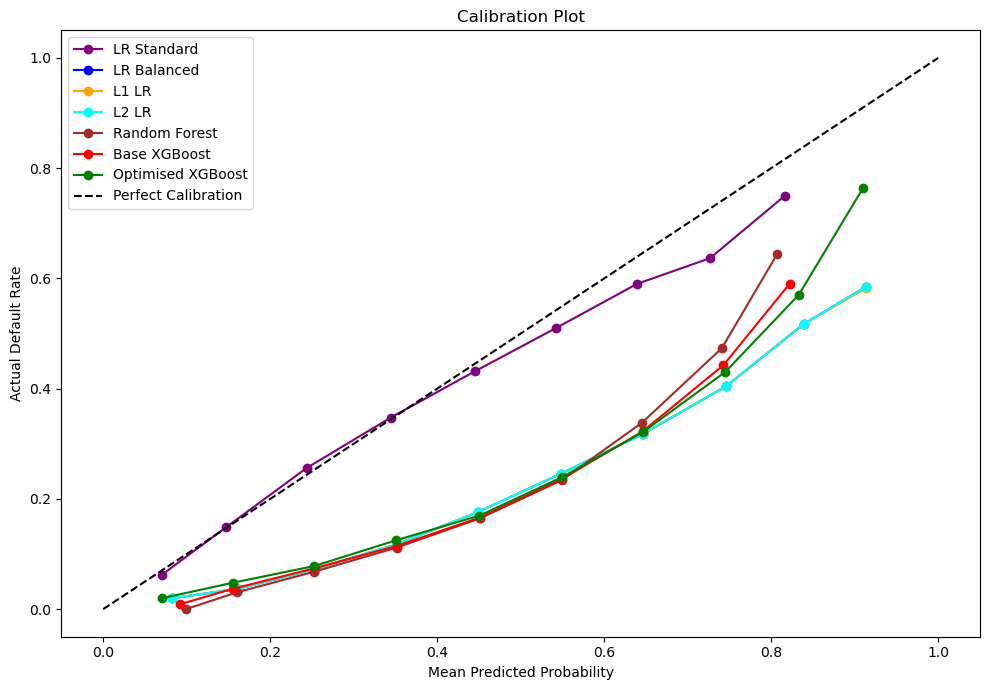

In [94]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(10, 7))

y_probs = [y_prob_lr, y_prob_lr_balanced, y_prob_l1, y_prob_l2, y_prob_rf, y_prob_xgb, y_prob_best_xgb]
labels = ['LR Standard', 'LR Balanced', 'L1 LR', 'L2 LR', 'Random Forest', 'Base XGBoost', 'Optimised XGBoost']
colours = ['purple', 'blue', 'orange', 'cyan', 'brown', 'red', 'green']

for i in range(len(y_probs)):
    prob_true, prob_pred = calibration_curve(y_test, y_probs[i], n_bins=10)
    ax.plot(prob_pred, prob_true, label=labels[i], color=colours[i], marker='o')

# Perfect calibration line
ax.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')

ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Actual Default Rate')
ax.set_title('Calibration Plot')
ax.legend()
plt.tight_layout()
plt.show()

This shows that the standard Linear Regression model is the best calibrated, while all the other models sit far below the diagonal, although they improve as the predicted probability increases. If one of these models were to actually be applied, I would investigate applying some sort of probability calibration to fix this systematic error but this is beyond the scope of this project.

Now I will calculate the KS Statistic for the key models

In [100]:
from scipy.stats import ks_2samp

models = {
    'LR Standard': y_prob_lr, 
    'LR Balanced': y_prob_lr_balanced,
    'Random Forest': y_prob_rf,
    'Base XGBoost': y_prob_xgb,
    'Optimised XGBoost': y_prob_best_xgb
}


for i in range(5): 
    name = list(models.keys())[i]
    prob = list(models.values())[i]

    prob_default = prob[y_test == 1]
    prob_non_default = prob[y_test == 0]

    ks_stat, _ = ks_2samp(prob_default, prob_non_default)
    
    print(f'{name} {ks_stat:.4f}')

LR Standard 0.3052
LR Balanced 0.3056
Random Forest 0.3045
Base XGBoost 0.3128
Optimised XGBoost 0.3282


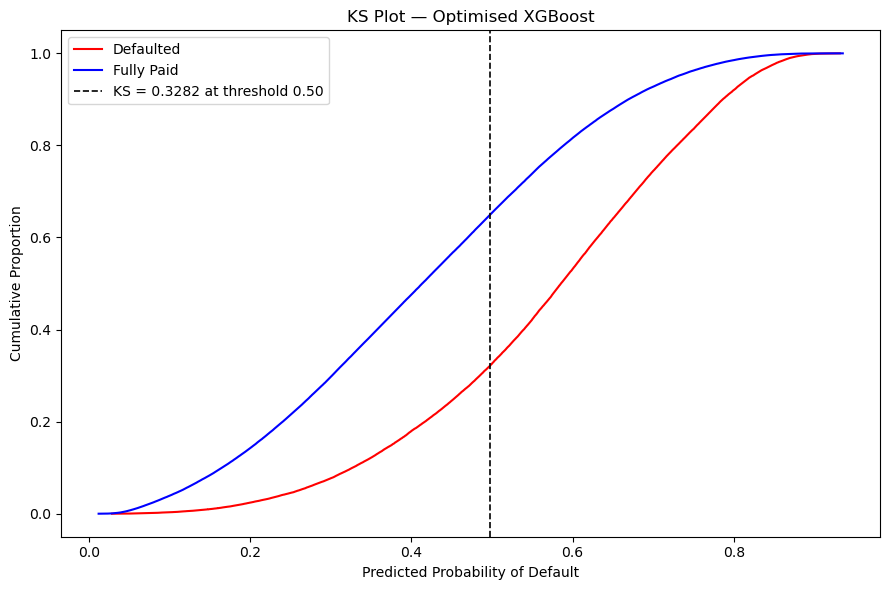

In [105]:
prob_default = y_prob_best_xgb[y_test == 1]
prob_non_default = y_prob_best_xgb[y_test == 0]

# sort in ascending order
sorted_default = np.sort(prob_default)
sorted_non_default = np.sort(prob_non_default)

# start building the CDF
cdf_default = np.linspace(0, 1, len(sorted_default))
cdf_non_default = np.linspace(0, 1, len(sorted_non_default))


cdf_non_default_interp = np.interp(sorted_default, sorted_non_default, cdf_non_default)

ks_values = np.abs(cdf_default - cdf_non_default_interp)
ks_stat_idx = np.argmax(ks_values)
ks_stat = ks_values[ks_stat_idx]
ks_x = sorted_default[ks_stat_idx]  # The probability threshold where the gap is largest

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(sorted_default, cdf_default, color='red', label='Defaulted')
ax.plot(sorted_non_default, cdf_non_default, color='blue', label='Fully Paid')

# Draw a vertical line at the point of maximum separation
ax.axvline(x=ks_x, color='black', linestyle='--', linewidth=1.2,
           label=f'KS = {ks_stat:.4f} at threshold {ks_x:.2f}')

ax.set_xlabel('Predicted Probability of Default')
ax.set_ylabel('Cumulative Proportion')
ax.set_title('KS Plot — Optimised XGBoost')
ax.legend()
plt.tight_layout()
plt.show()

The results back up what I found previously. The optimised XGBoost model is the best performing model but there isn't a huge difference between it and the other, more basic models. The KS Statistic of $0.3282$ shows the model is good at predicting defaulters.  
As expected in the graph, non defaulters are more likely to be predicted at lower probabilities so this curve rises more steeply. The maximum gap falls at exactly $0.5$ which is the default selection of the model anyway, so it is close to optimal in this respect. However in practice this would be adjusted depending on the risk profile of the bank.

Now I will perform a stability analysis.  
A random train/test split assumes that loans from all time periods are interchangable, however in practice models are trained on known/past data and deployed on future data.  

To test whether the model holds up over time, I will split the data again, chronologically this time.  
- **Training Data: $207-2014$** - the model will train on the older loans
- **Testing Data: $2015-2018$** - it is then evaluated on newer loans

If performance drops significantly, it is a sign that the model is picking up patterns that don't generalise over time. This is a big problem in credit risk as economic conditions can change a lot between training and deployment times.  
The optimised XGBoost parameters found earlier will be used, but it will be retrained from scratch on the new training data.

In [164]:
#df includes issue_d
#term 
#there are 2 options here - 36 months and 60 months
df['term'] = df['term'].astype(str).str.strip()
df['term'] = df.term.map({'36 months': 36, '60 months': 60})

#sub_grade has a natural order from A1 through to G5
sub_grade_order = ['A1', 'A2', 'A3', 'A4', 'A5', 
                   'B1', 'B2', 'B3', 'B4', 'B5', 
                   'C1', 'C2', 'C3', 'C4', 'C5', 
                   'D1', 'D2', 'D3', 'D4', 'D5',
                   'E1', 'E2', 'E3', 'E4', 'E5',
                   'F1', 'F2', 'F3', 'F4', 'F5', 
                   'G1', 'G2', 'G3', 'G4', 'G5'] 
df['sub_grade'] = df.sub_grade.map({grade: i+1 for i, grade in enumerate(sub_grade_order)})

#emp_length also has a clear order. 'Unknown' will be set as -1 since this was shown to have a more negative impact.
emp_length_order = {
    'Unknown': -1, 
    '< 1 year': 0, 
    '1 year': 1, 
    '2 years': 2, 
    '3 years': 3, 
    '4 years': 4, 
    '5 years': 5, 
    '6 years': 6, 
    '7 years': 7, 
    '8 years': 8, 
    '9 years': 9, 
    '10+ years': 10
}
df['emp_length'] = df.emp_length.map(emp_length_order)

#The rest don't have a real order
dummies = ['home_ownership', 'verification_status', 'purpose']
df = pd.get_dummies(df, columns=dummies, drop_first=True)

print(df.select_dtypes(include='object').columns.tolist())

[]


In [165]:
#Now split the explanatory variables and response variable
X_dates = df.drop(columns=['default'])
y_dates = df['default']

In [172]:
X_dates['issue_d'] = pd.to_datetime(X_dates['issue_d'])

# Boolean masks — True for rows in each time period
mask_train = X_dates['issue_d'] < '2015-01-01'
mask_test = X_dates['issue_d'] >= '2015-01-01'


X_dates_train = X_dates[mask_train].drop(columns='issue_d')
X_dates_test = X_dates[mask_test].drop(columns='issue_d')
y_dates_train = y_dates[mask_train]
y_dates_test = y_dates[mask_test]

print(f'Dates train size: {len(X_dates_train):,} ({mask_train.sum() / len(X_dates):.1%} of data)')
print(f'Dates test size:  {len(X_dates_test):,} ({mask_test.sum() / len(X_dates):.1%} of data)')
print(f'Dates train default rate: {y_dates_train.mean():.3f}')
print(f'Dates test default rate:  {y_dates_test.mean():.3f}')

Dates train size: 452,146 (34.3% of data)
Dates test size:  867,961 (65.7% of data)
Dates train default rate: 0.170
Dates test default rate:  0.214


In [173]:
pickle.dump((X_dates_train, X_dates_test, y_dates_train, y_dates_test), open('train_test_split_dates.pkl', 'wb'))

XGBoost done
XGBoost Results
----------------
              precision    recall  f1-score   support

           0       0.87      0.69      0.77    682317
           1       0.35      0.62      0.45    185644

    accuracy                           0.67    867961
   macro avg       0.61      0.65      0.61    867961
weighted avg       0.76      0.67      0.70    867961

ROC-AUC: 0.7132


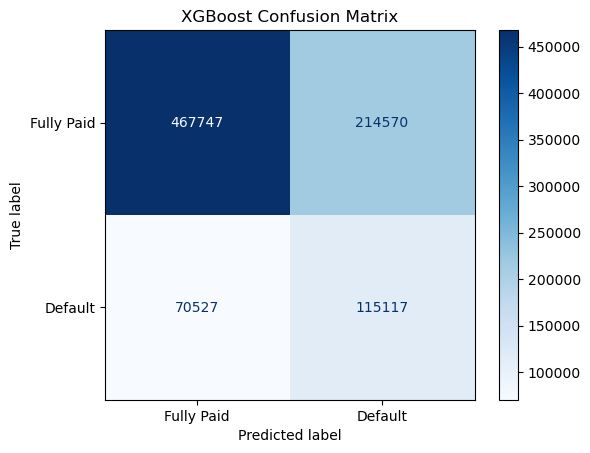

In [174]:
xgb_dates = XGBClassifier(
    n_estimators=300, 
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.3,
    scale_pos_weight=len(y_dates_train[y_dates_train==0]) / len(y_dates_train[y_dates_train==1]),
    random_state=92,
    n_jobs=-1,
    eval_metric='auc'
)

xgb_dates.fit(X_dates_train, y_dates_train)
pickle.dump(xgb_dates, open('xgb_dates.pkl', 'wb'))
print('XGBoost done')

y_pred_dates_xgb = xgb_dates.predict(X_dates_test)
y_prob_dates_xgb = xgb_dates.predict_proba(X_dates_test)[:, 1]

print('XGBoost Results')
print('----------------')
print(classification_report(y_dates_test, y_pred_dates_xgb))
print(f'ROC-AUC: {roc_auc_score(y_dates_test, y_prob_dates_xgb):.4f}')

cm_xgb_dates = confusion_matrix(y_dates_test, y_pred_dates_xgb)
disp_xgb_dates = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_dates, display_labels=['Fully Paid', 'Default'])
disp_xgb_dates.plot(cmap='Blues')
plt.title('XGBoost Confusion Matrix')
plt.show()

This shows that the model holds up reasonably well over time, there is a slight drop off of around $0.012$ in the AUC score but if the model was picking up on patterns that didn't hold up over time, there would be a much steeper drop. This shows it learned genuine signals about lenders instead of time specific signals. There is a slight drop in recall along with a slight increase in precision, showing that less defaults are flagged but it is more accurate when it does flag.

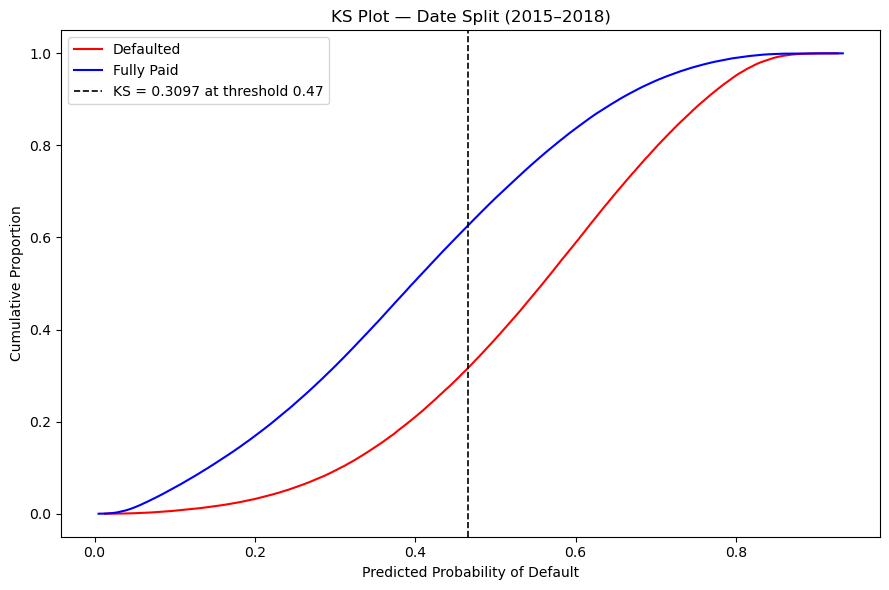

 Random Split vs Temporal Split 
Metric                  Random Split  Temporal Split
----------------------------------------------------
AUC                           0.7248          0.7132
KS                            0.3282          0.3097


In [177]:
# I will compare with the random split

prob_default_dates = y_prob_dates_xgb[y_dates_test == 1]
prob_non_default_dates = y_prob_dates_xgb[y_dates_test == 0]
# sort in ascending order
sorted_default_dates = np.sort(prob_default_dates)
sorted_non_default_dates = np.sort(prob_non_default_dates)
# start building the CDF
cdf_default_dates = np.linspace(0, 1, len(sorted_default_dates))
cdf_non_default_dates = np.linspace(0, 1, len(sorted_non_default_dates))
cdf_non_default_interp_dates = np.interp(sorted_default_dates, sorted_non_default_dates, cdf_non_default_dates)
ks_values_dates = np.abs(cdf_default_dates - cdf_non_default_interp_dates)
ks_stat_idx_dates = np.argmax(ks_values_dates)
ks_stat_dates = ks_values_dates[ks_stat_idx_dates]
ks_x_dates = sorted_default_dates[ks_stat_idx_dates]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(sorted_default_dates, cdf_default_dates, color='red', label='Defaulted')
ax.plot(sorted_non_default_dates, cdf_non_default_dates, color='blue', label='Fully Paid')
ax.axvline(x=ks_x_dates, color='black', linestyle='--', linewidth=1.2,
           label=f'KS = {ks_stat_dates:.4f} at threshold {ks_x_dates:.2f}')
ax.set_xlabel('Predicted Probability of Default')
ax.set_ylabel('Cumulative Proportion')
ax.set_title('KS Plot — Date Split (2015–2018)')
ax.legend()
plt.tight_layout()
plt.show()

print(" Random Split vs Temporal Split ")
print(f"{'Metric':<20} {'Random Split':>15} {'Temporal Split':>15}")
print("-" * 52)
print(f"{'AUC':<20} {'0.7248':>15} {'0.7132':>15}")
print(f"{'KS':<20} {'0.3282':>15} {ks_stat_dates:>15.4f}")

This backs up what is seen from before, the KS statistic also slightly decreases to $0.3097$, with the decrease being small we can say that it is stable over time.